In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif

In [2]:
# cargar el dataset
df = pd.read_csv("Resultados_Saber11.csv")
df.info()

FileNotFoundError: [Errno 2] No such file or directory: 'Resultados_Saber11.csv'

In [ ]:
df.describe()

,PERIODO,COLE_COD_DANE_ESTABLECIMIENTO,COLE_COD_DANE_SEDE,COLE_COD_DEPTO_UBICACION,COLE_COD_MCPIO_UBICACION,COLE_CODIGO_ICFES,ESTU_COD_DEPTO_PRESENTACION,ESTU_COD_MCPIO_PRESENTACION,ESTU_COD_RESIDE_DEPTO,ESTU_COD_RESIDE_MCPIO,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
count,563370.000000,5.633700e+05,5.633700e+05,563370.000000,563370.000000,563370.000000,563370.000000,563370.000000,563369.000000,563369.000000,563370.000000,563370.000000,563370.000000,563370.000000,563370.000000,563370.000000
mean,20161.976756,2.074211e+11,2.086447e+11,33.033694,33261.530621,91410.286066,32.968838,33177.016398,33.167365,33216.820113,52.427105,51.175829,50.838396,52.878634,52.771587,259.777565
std,0.150678,9.439559e+10,9.770464e+10,26.755536,26779.054178,95931.900294,26.806453,26831.411849,135.849562,26797.567134,12.189795,12.065848,10.965044,9.891802,9.702072,48.629499
min,20161.000000,1.050010e+11,1.050010e+11,5.000000,5001.000000,59.000000,5.000000,5001.000000,5.000000,5001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20162.000000,1.175240e+11,1.176140e+11,11.000000,11001.000000,29504.000000,11.000000,11001.000000,11.000000,11001.000000,44.000000,42.000000,43.000000,46.000000,46.000000,223.000000
50%,20162.000000,1.760010e+11,1.760010e+11,20.000000,20570.000000,80655.000000,20.000000,20175.000000,20.000000,20250.000000,51.000000,51.000000,51.000000,53.000000,53.000000,258.000000
75%,20162.000000,3.080010e+11,3.080011e+11,54.000000,54518.000000,126961.000000,54.000000,54518.000000,54.000000,54518.000000,59.000000,59.000000,59.000000,60.000000,59.000000,293.000000
max,20162.000000,5.684320e+11,8.470010e+11,99.000000,99773.000000,662858.000000,99.000000,99773.000000,99999.000000,99999.000000,100.000000,100.000000,100.000000,100.000000,100.000000,494.000000


#### Datos faltantes

In [ ]:
faltantes = df.isna().sum()
print(faltantes)

PERIODO                              0
ESTU_TIPODOCUMENTO                   0
ESTU_CONSECUTIVO                     0
COLE_AREA_UBICACION                  0
COLE_BILINGUE                    72802
COLE_CALENDARIO                      0
COLE_CARACTER                     5282
COLE_COD_DANE_ESTABLECIMIENTO        0
COLE_COD_DANE_SEDE                   0
COLE_COD_DEPTO_UBICACION             0
COLE_COD_MCPIO_UBICACION             0
COLE_CODIGO_ICFES                    0
COLE_DEPTO_UBICACION                 0
COLE_GENERO                          0
COLE_JORNADA                         0
COLE_MCPIO_UBICACION                 0
COLE_NATURALEZA                      0
COLE_NOMBRE_ESTABLECIMIENTO          0
COLE_NOMBRE_SEDE                     0
COLE_SEDE_PRINCIPAL                  0
ESTU_COD_DEPTO_PRESENTACION          0
ESTU_COD_MCPIO_PRESENTACION          0
ESTU_COD_RESIDE_DEPTO                1
ESTU_COD_RESIDE_MCPIO                1
ESTU_DEPTO_PRESENTACION              0
ESTU_DEPTO_RESIDE        

In [ ]:
df.dropna(inplace=True)
faltantes = df.isna().sum()
print(faltantes)

PERIODO                          0
ESTU_TIPODOCUMENTO               0
ESTU_CONSECUTIVO                 0
COLE_AREA_UBICACION              0
COLE_BILINGUE                    0
COLE_CALENDARIO                  0
COLE_CARACTER                    0
COLE_COD_DANE_ESTABLECIMIENTO    0
COLE_COD_DANE_SEDE               0
COLE_COD_DEPTO_UBICACION         0
COLE_COD_MCPIO_UBICACION         0
COLE_CODIGO_ICFES                0
COLE_DEPTO_UBICACION             0
COLE_GENERO                      0
COLE_JORNADA                     0
COLE_MCPIO_UBICACION             0
COLE_NATURALEZA                  0
COLE_NOMBRE_ESTABLECIMIENTO      0
COLE_NOMBRE_SEDE                 0
COLE_SEDE_PRINCIPAL              0
ESTU_COD_DEPTO_PRESENTACION      0
ESTU_COD_MCPIO_PRESENTACION      0
ESTU_COD_RESIDE_DEPTO            0
ESTU_COD_RESIDE_MCPIO            0
ESTU_DEPTO_PRESENTACION          0
ESTU_DEPTO_RESIDE                0
ESTU_ESTADOINVESTIGACION         0
ESTU_ESTUDIANTE                  0
ESTU_FECHANACIMIENTO

In [ ]:
# duplicados
num_dup = df.duplicated().sum()
print(f"Filas duplicadas: {num_dup}")

# Eliminar duplicados
df_limpio = df.drop_duplicates()

Filas duplicadas: 2006


In [ ]:
df_limpio['ESTU_FECHANACIMIENTO']

0         06/02/1999
1         22/12/1999
2         04/06/1997
3         02/07/1996
4         21/10/1998
             ...    
563365    25/05/1999
563366    21/08/1999
563367    28/10/1999
563368    16/09/1997
563369    25/02/2000
Name: ESTU_FECHANACIMIENTO, Length: 485421, dtype: object

#### Agregar la edad

In [ ]:
# Convertir a datetime con formato día/mes/año
df_limpio['ESTU_FECHANACIMIENTO'] = pd.to_datetime(
    df_limpio['ESTU_FECHANACIMIENTO'],
    format='%d/%m/%Y',
    dayfirst=True,     
    errors='coerce'     
)
df_limpio['ESTU_FECHANACIMIENTO']

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\445765070.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio['ESTU_FECHANACIMIENTO'] = pd.to_datetime(


0        1999-02-06
1        1999-12-22
2        1997-06-04
3        1996-07-02
4        1998-10-21
            ...    
563365   1999-05-25
563366   1999-08-21
563367   1999-10-28
563368   1997-09-16
563369   2000-02-25
Name: ESTU_FECHANACIMIENTO, Length: 485421, dtype: datetime64[ns]

In [ ]:

# Mapear PERIODO → fecha exacta de examen
s = df_limpio['PERIODO'].astype(str)
df_limpio['FECHA_EXAMEN'] = pd.to_datetime(
    np.where(
        s.str.endswith('1'),
        '31/07/' + s.str[:4],    # periodo “YYYY1” → 31 de julio de YYYY
        '20/11/' + s.str[:4]     # periodo “YYYY2” → 20 de noviembre de YYYY
    ),
    format='%d/%m/%Y',
    dayfirst=True
)

# Calcular la edad “entera” al día del examen, de forma vectorizada
# Basado en: años de diferencia – 1 si aún no cumple en ese año
años_ex = df_limpio['FECHA_EXAMEN'].dt.year
meses_ex = df_limpio['FECHA_EXAMEN'].dt.month
días_ex  = df_limpio['FECHA_EXAMEN'].dt.day

años_bn = df_limpio['ESTU_FECHANACIMIENTO'].dt.year
meses_bn = df_limpio['ESTU_FECHANACIMIENTO'].dt.month
días_bn  = df_limpio['ESTU_FECHANACIMIENTO'].dt.day

edad_base = años_ex - años_bn
no_cumple = (
    (meses_ex  < meses_bn) |
    ((meses_ex == meses_bn) & (días_ex < días_bn))
)

df_limpio['EDAD'] = edad_base - no_cumple.astype(int)

# 3. Verificación rápida
print(df_limpio[['ESTU_FECHANACIMIENTO','FECHA_EXAMEN','EDAD']].head())
print(df_limpio['EDAD'].describe())


C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\1900524658.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio['FECHA_EXAMEN'] = pd.to_datetime(


  ESTU_FECHANACIMIENTO FECHA_EXAMEN  EDAD
0           1999-02-06   2016-07-31  17.0
1           1999-12-22   2016-07-31  16.0
2           1997-06-04   2016-07-31  19.0
3           1996-07-02   2016-07-31  20.0
4           1998-10-21   2016-07-31  17.0
count    485397.000000
mean         17.766649
std           3.663838
min          -3.000000
25%          16.000000
50%          17.000000
75%          18.000000
max         130.000000
Name: EDAD, dtype: float64


C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\1900524658.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio['EDAD'] = edad_base - no_cumple.astype(int)


In [ ]:
# umbral de edad
min_age, max_age = 12, 30

# Filtrar
df_limpio = df_limpio[
    df_limpio['EDAD'].between(min_age, max_age)
].copy()

print(df_limpio['EDAD'].describe())

count    476354.000000
mean         17.369534
std           1.716634
min          12.000000
25%          16.000000
50%          17.000000
75%          18.000000
max          30.000000
Name: EDAD, dtype: float64


#### Eliminar columnas innecesarias

In [ ]:
df_limpio.nunique().sort_values()

ESTU_ESTUDIANTE                       1
ESTU_ESTADOINVESTIGACION              1
ESTU_PRIVADO_LIBERTAD                 1
PERIODO                               2
COLE_SEDE_PRINCIPAL                   2
COLE_NATURALEZA                       2
COLE_BILINGUE                         2
COLE_AREA_UBICACION                   2
FAMI_TIENEAUTOMOVIL                   2
FAMI_TIENECOMPUTADOR                  2
FECHA_EXAMEN                          2
FAMI_TIENELAVADORA                    2
FAMI_TIENEINTERNET                    2
ESTU_GENERO                           2
COLE_GENERO                           3
COLE_CALENDARIO                       3
COLE_CARACTER                         4
DESEMP_INGLES                         5
FAMI_ESTRATOVIVIENDA                  6
COLE_JORNADA                          6
FAMI_CUARTOSHOGAR                    10
FAMI_EDUCACIONMADRE                  11
FAMI_EDUCACIONPADRE                  11
FAMI_PERSONASHOGAR                   12
ESTU_TIPODOCUMENTO                   12


In [ ]:
cols_a_eliminar = [
    # constantes
    'ESTU_ESTUDIANTE', 'ESTU_ESTADOINVESTIGACION', 'ESTU_PRIVADO_LIBERTAD',
    # IDs
    'ESTU_CONSECUTIVO', 'COLE_COD_DEPTO_UBICACION',
    'COLE_COD_DANE_ESTABLECIMIENTO','COLE_COD_DANE_SEDE','COLE_CODIGO_ICFES',
    # fechas
    'ESTU_FECHANACIMIENTO','FECHA_EXAMEN',
    # nombres
    'COLE_NOMBRE_ESTABLECIMIENTO','COLE_NOMBRE_SEDE',
    # códigos de municipio (altísima cardinalidad)
    'ESTU_COD_MCPIO_PRESENTACION','ESTU_COD_RESIDE_MCPIO','COLE_COD_MCPIO_UBICACION',
    # otras columna a eliminar
    'ESTU_TIPODOCUMENTO', 'COLE_MCPIO_UBICACION','COLE_NATURALEZA', 'COLE_SEDE_PRINCIPAL',
    'ESTU_COD_DEPTO_PRESENTACION', 'ESTU_COD_RESIDE_DEPTO', 'ESTU_DEPTO_PRESENTACION', 
    'ESTU_MCPIO_PRESENTACION', 'ESTU_MCPIO_RESIDE', 'COLE_AREA_UBICACION', 
    'COLE_DEPTO_UBICACION'
]

df_model = df_limpio.drop(columns=cols_a_eliminar)
df_model.nunique().sort_values()


PERIODO                       2
COLE_BILINGUE                 2
ESTU_GENERO                   2
FAMI_TIENEAUTOMOVIL           2
FAMI_TIENEINTERNET            2
FAMI_TIENELAVADORA            2
FAMI_TIENECOMPUTADOR          2
COLE_GENERO                   3
COLE_CALENDARIO               3
COLE_CARACTER                 4
DESEMP_INGLES                 5
COLE_JORNADA                  6
FAMI_ESTRATOVIVIENDA          6
FAMI_CUARTOSHOGAR            10
FAMI_EDUCACIONPADRE          11
FAMI_EDUCACIONMADRE          11
FAMI_PERSONASHOGAR           12
EDAD                         19
ESTU_DEPTO_RESIDE            34
ESTU_NACIONALIDAD            51
ESTU_PAIS_RESIDE             51
PUNT_INGLES                  66
PUNT_LECTURA_CRITICA         68
PUNT_C_NATURALES             72
PUNT_SOCIALES_CIUDADANAS     74
PUNT_MATEMATICAS             79
PUNT_GLOBAL                 364
dtype: int64

#### Limpieza 

In [ ]:
for c in ['ESTU_PAIS_RESIDE','ESTU_NACIONALIDAD', 'ESTU_DEPTO_RESIDE']:
    df_model[c] = df_model[c].str.strip().str.lower().str.normalize('NFKD') \
                            .str.replace(r'[\u0300-\u036f]', '', regex=True)

In [ ]:
def agrupar_raros(col, umbral=0.01):
    # frecuencias relativas
    frec = df_model[col].value_counts(normalize=True)
    # Filtra las categorías por debajo del umbral
    raros = frec[frec < umbral]
    # Imprime las categorías que se agruparán
    if len(raros) > 0:
        print(f"\nColumna '{col}': se agruparán {len(raros)} categorías (frec < {umbral*100:.2f}%):")
        print(raros.to_string())
    else:
        print(f"\nColumna '{col}': no hay categorías con f < {umbral*100:.2f}%")
    # Reemplaza
    df_model[col] = df_model[col].replace(raros.index, 'otro')


for c in ['ESTU_PAIS_RESIDE','ESTU_DEPTO_RESIDE', 'ESTU_NACIONALIDAD']:
    agrupar_raros(c, umbral=0.005)



Columna 'ESTU_PAIS_RESIDE': se agruparán 50 categorías (frec < 0.50%):
ESTU_PAIS_RESIDE
venezuela                 0.000210
estados unidos            0.000174
ecuador                   0.000055
espana                    0.000055
mexico                    0.000031
comoras                   0.000031
argentina                 0.000025
alemania                  0.000019
francia                   0.000019
costa rica                0.000015
italia                    0.000015
peru                      0.000015
chile                     0.000013
corea del norte           0.000013
corea del sur             0.000013
panama                    0.000013
brasil                    0.000008
japon                     0.000008
reino unido               0.000008
uruguay                   0.000006
territorios palestinos    0.000006
el salvador               0.000006
paises bajos - holanda    0.000006
bolivia                   0.000006
cuba                      0.000006
canada                    0.000004
a

In [ ]:
df_model['ESTU_PAIS_RESIDE'].unique()

array(['colombia', 'otro'], dtype=object)

In [ ]:
df_model['ESTU_NACIONALIDAD'].unique()

array(['colombia', 'otro'], dtype=object)

In [ ]:
df_model

,PERIODO,COLE_BILINGUE,COLE_CALENDARIO,COLE_CARACTER,COLE_GENERO,COLE_JORNADA,ESTU_DEPTO_RESIDE,ESTU_GENERO,ESTU_NACIONALIDAD,ESTU_PAIS_RESIDE,...,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,DESEMP_INGLES,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL,EDAD
0,20161,N,B,TÉCNICO/ACADÉMICO,MASCULINO,COMPLETA,bogota,M,colombia,colombia,...,Si,Si,B+,92,100,96,83,69,437,17.0
1,20161,N,B,TÉCNICO,MIXTO,MAÑANA,valle,M,colombia,colombia,...,Si,Si,A2,64,71,68,78,69,355,16.0
2,20161,S,B,ACADÉMICO,MIXTO,COMPLETA,valle,M,colombia,colombia,...,Si,Si,B+,95,73,78,72,60,363,19.0
3,20161,S,B,ACADÉMICO,MIXTO,MAÑANA,valle,M,colombia,colombia,...,Si,Si,B1,82,78,68,70,60,350,20.0
4,20161,S,B,ACADÉMICO,MIXTO,COMPLETA,risaralda,M,colombia,colombia,...,Si,Si,B+,90,84,74,69,71,378,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563365,20162,N,A,TÉCNICO/ACADÉMICO,MIXTO,MAÑANA,narino,F,colombia,colombia,...,No,No,A-,48,62,54,61,58,290,17.0
563366,20162,N,A,TÉCNICO/ACADÉMICO,MIXTO,MAÑANA,caqueta,F,colombia,colombia,...,No,No,A-,40,42,47,50,53,236,17.0
563367,20162,N,A,ACADÉMICO,MIXTO,MAÑANA,magdalena,M,colombia,colombia,...,Si,No,A1,56,55,38,50,47,242,17.0
563368,20162,N,A,TÉCNICO/ACADÉMICO,MIXTO,MAÑANA,santander,M,colombia,colombia,...,Si,Si,A1,52,60,50,60,52,276,19.0


In [ ]:
df_model = df_model.drop(columns=['ESTU_PAIS_RESIDE', 'ESTU_NACIONALIDAD'])

In [ ]:
df_model['ESTU_DEPTO_RESIDE'].unique()

array(['bogota', 'valle', 'risaralda', 'cauca', 'caldas', 'narino',
       'cundinamarca', 'antioquia', 'atlantico', 'la guajira', 'bolivar',
       'santander', 'cordoba', 'cesar', 'quindio', 'magdalena', 'otro',
       'norte santander', 'sucre', 'caqueta', 'boyaca', 'choco', 'tolima',
       'meta', 'huila', 'putumayo', 'arauca', 'casanare'], dtype=object)

In [ ]:
df_model['FAMI_CUARTOSHOGAR'].value_counts()

FAMI_CUARTOSHOGAR
Tres          198737
Dos           175646
Cuatro         59586
Uno            18658
Cinco          15257
Seis            4983
Siete           1760
Ocho             916
Diez o más       481
Nueve            330
Name: count, dtype: int64

In [ ]:
# Lista de no cuartos a agrupar
niveles = ['Cinco', 'Seis', 'Siete', 'Ocho', 'Nueve', 'Diez o más']

# Reemplazar por 'Cinco o más'
df_model['FAMI_CUARTOSHOGAR'] = df_model['FAMI_CUARTOSHOGAR'] \
    .replace(niveles, 'Cinco o más')

# Print del resultado
df_model['FAMI_CUARTOSHOGAR'].value_counts()


FAMI_CUARTOSHOGAR
Tres           198737
Dos            175646
Cuatro          59586
Cinco o más     23727
Uno             18658
Name: count, dtype: int64

In [ ]:
df_model.FAMI_PERSONASHOGAR.value_counts()

FAMI_PERSONASHOGAR
Cuatro        146491
Cinco         109014
Tres           86365
Seis           53029
Dos            26393
Siete          24789
Ocho           12932
Nueve           5683
Diez            3987
Doce o más      3117
Una             2805
Once            1749
Name: count, dtype: int64

In [ ]:
# Lista de no. familiares a agrupar
niveles = ['Siete', 'Ocho', 'Nueve', 'Diez', 'Once', 'Doce o más']

# Reemplazar por 'Siete o más'
df_model['FAMI_PERSONASHOGAR'] = df_model['FAMI_PERSONASHOGAR'] \
    .replace(niveles, 'Siete o más')

# Print del resultado
df_model.FAMI_PERSONASHOGAR.value_counts()

FAMI_PERSONASHOGAR
Cuatro         146491
Cinco          109014
Tres            86365
Seis            53029
Siete o más     52257
Dos             26393
Una              2805
Name: count, dtype: int64

#### Estadísticas

Los puntajes en general están altamente correlacionados entre sí, se podría agrupar dejando a inglés separada o trabajar únicamente con el global


In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 476354 entries, 0 to 563369
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   PERIODO                   476354 non-null  int64  
 1   COLE_BILINGUE             476354 non-null  object 
 2   COLE_CALENDARIO           476354 non-null  object 
 3   COLE_CARACTER             476354 non-null  object 
 4   COLE_GENERO               476354 non-null  object 
 5   COLE_JORNADA              476354 non-null  object 
 6   ESTU_DEPTO_RESIDE         476354 non-null  object 
 7   ESTU_GENERO               476354 non-null  object 
 8   FAMI_CUARTOSHOGAR         476354 non-null  object 
 9   FAMI_EDUCACIONMADRE       476354 non-null  object 
 10  FAMI_EDUCACIONPADRE       476354 non-null  object 
 11  FAMI_ESTRATOVIVIENDA      476354 non-null  object 
 12  FAMI_PERSONASHOGAR        476354 non-null  object 
 13  FAMI_TIENEAUTOMOVIL       476354 non-null  object

In [ ]:
corr = df_model[['PUNT_MATEMATICAS','PUNT_LECTURA_CRITICA',
                 'PUNT_C_NATURALES','PUNT_SOCIALES_CIUDADANAS','PUNT_INGLES']].corr()
corr

,PUNT_MATEMATICAS,PUNT_LECTURA_CRITICA,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
PUNT_MATEMATICAS,1.000000,0.745078,0.816878,0.778272,0.684141
PUNT_LECTURA_CRITICA,0.745078,1.000000,0.747775,0.798429,0.663525
PUNT_C_NATURALES,0.816878,0.747775,1.000000,0.800785,0.695868
PUNT_SOCIALES_CIUDADANAS,0.778272,0.798429,0.800785,1.000000,0.694888
PUNT_INGLES,0.684141,0.663525,0.695868,0.694888,1.000000


In [ ]:
cols_a_eliminar = [
    # Puntajes individuales
    'DESEMP_INGLES', 'PUNT_INGLES', 'PUNT_MATEMATICAS', 'PUNT_SOCIALES_CIUDADANAS',
    'PUNT_C_NATURALES', 'PUNT_LECTURA_CRITICA',
    # Perido
    'PERIODO'
    ]

df_model = df_model.drop(columns=cols_a_eliminar)
df_model.nunique().sort_values()

COLE_BILINGUE             2
ESTU_GENERO               2
FAMI_TIENEINTERNET        2
FAMI_TIENELAVADORA        2
FAMI_TIENEAUTOMOVIL       2
FAMI_TIENECOMPUTADOR      2
COLE_GENERO               3
COLE_CALENDARIO           3
COLE_CARACTER             4
FAMI_CUARTOSHOGAR         5
FAMI_ESTRATOVIVIENDA      6
COLE_JORNADA              6
FAMI_PERSONASHOGAR        7
FAMI_EDUCACIONMADRE      11
FAMI_EDUCACIONPADRE      11
EDAD                     19
ESTU_DEPTO_RESIDE        28
PUNT_GLOBAL             364
dtype: int64

In [ ]:
df_model[['EDAD','PUNT_GLOBAL']].describe().T
df_model[['EDAD','PUNT_GLOBAL']].skew(), df_model[['EDAD','PUNT_GLOBAL']].kurtosis()

(EDAD           3.095563
 PUNT_GLOBAL    0.264470
 dtype: float64,
 EDAD           15.109649
 PUNT_GLOBAL    -0.266235
 dtype: float64)

In [ ]:
for c in df_model.select_dtypes('object'):
    print(c)
    print(df_model[c].value_counts(dropna=False))
    print(df_model[c].value_counts(normalize=True).mul(100).round(2), '\n')

COLE_BILINGUE
COLE_BILINGUE
N    467033
S      9321
Name: count, dtype: int64
COLE_BILINGUE
N    98.04
S     1.96
Name: proportion, dtype: float64 

COLE_CALENDARIO
COLE_CALENDARIO
A       462665
B        12008
OTRO      1681
Name: count, dtype: int64
COLE_CALENDARIO
A       97.13
B        2.52
OTRO     0.35
Name: proportion, dtype: float64 

COLE_CARACTER
COLE_CARACTER
ACADÉMICO            247599
TÉCNICO/ACADÉMICO    172849
TÉCNICO               54698
NO APLICA              1208
Name: count, dtype: int64
COLE_CARACTER
ACADÉMICO            51.98
TÉCNICO/ACADÉMICO    36.29
TÉCNICO              11.48
NO APLICA             0.25
Name: proportion, dtype: float64 

COLE_GENERO
COLE_GENERO
MIXTO        455349
FEMENINO      15985
MASCULINO      5020
Name: count, dtype: int64
COLE_GENERO
MIXTO        95.59
FEMENINO      3.36
MASCULINO     1.05
Name: proportion, dtype: float64 

COLE_JORNADA
COLE_JORNADA
MAÑANA      251846
COMPLETA     99068
TARDE        71157
NOCHE        28889
SABATINA     234

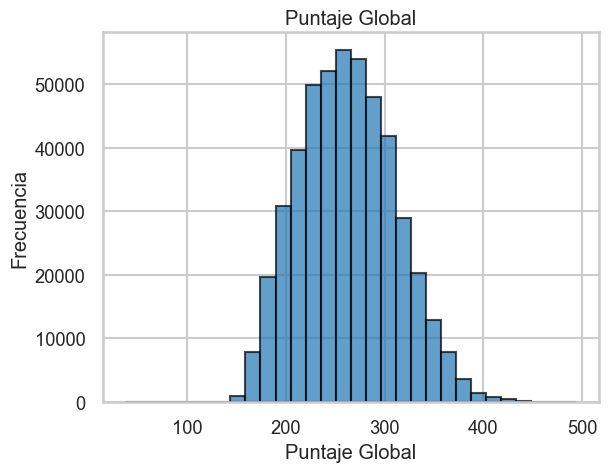

In [ ]:
# Crear histograma
plt.figure()
plt.hist(df_model['PUNT_GLOBAL'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Puntaje Global')
plt.xlabel('Puntaje Global')
plt.ylabel('Frecuencia')
plt.show()

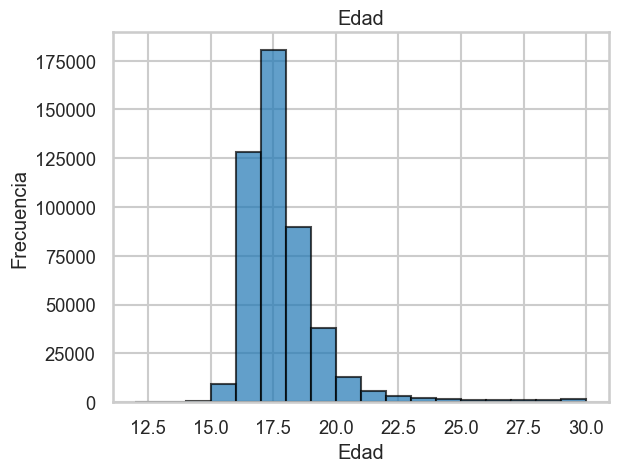

In [ ]:
# Crear histograma
plt.figure()
plt.hist(df_model['EDAD'], bins=18, edgecolor='black', alpha=0.7)
plt.title('Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

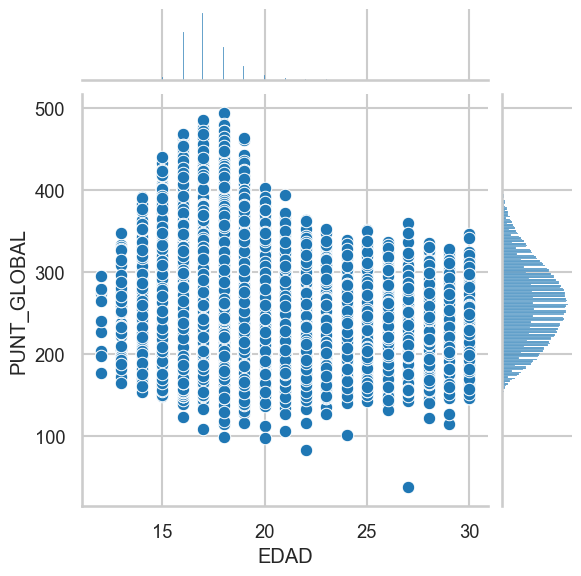

In [ ]:
import seaborn as sns
sns.jointplot(x='EDAD', y='PUNT_GLOBAL', data=df_model, kind='scatter')

In [ ]:
df_model

,COLE_BILINGUE,COLE_CALENDARIO,COLE_CARACTER,COLE_GENERO,COLE_JORNADA,ESTU_DEPTO_RESIDE,ESTU_GENERO,FAMI_CUARTOSHOGAR,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENEAUTOMOVIL,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,PUNT_GLOBAL,EDAD
0,N,B,TÉCNICO/ACADÉMICO,MASCULINO,COMPLETA,bogota,M,Tres,Postgrado,Educación profesional completa,Estrato 4,Tres,Si,Si,Si,Si,437,17.0
1,N,B,TÉCNICO,MIXTO,MAÑANA,valle,M,Dos,Postgrado,Secundaria (Bachillerato) completa,Estrato 3,Tres,Si,Si,Si,Si,355,16.0
2,S,B,ACADÉMICO,MIXTO,COMPLETA,valle,M,Cuatro,Educación profesional incompleta,Educación profesional completa,Estrato 6,Cinco,Si,Si,Si,Si,363,19.0
3,S,B,ACADÉMICO,MIXTO,MAÑANA,valle,M,Tres,Educación profesional completa,Educación profesional completa,Estrato 6,Tres,Si,Si,Si,Si,350,20.0
4,S,B,ACADÉMICO,MIXTO,COMPLETA,risaralda,M,Dos,Postgrado,Educación profesional completa,Estrato 6,Dos,Si,Si,Si,Si,378,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563365,N,A,TÉCNICO/ACADÉMICO,MIXTO,MAÑANA,narino,F,Tres,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Estrato 1,Seis,No,No,No,No,290,17.0
563366,N,A,TÉCNICO/ACADÉMICO,MIXTO,MAÑANA,caqueta,F,Dos,Primaria incompleta,Secundaria (Bachillerato) incompleta,Estrato 1,Cinco,No,No,No,No,236,17.0
563367,N,A,ACADÉMICO,MIXTO,MAÑANA,magdalena,M,Cuatro,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Estrato 2,Cuatro,No,No,Si,No,242,17.0
563368,N,A,TÉCNICO/ACADÉMICO,MIXTO,MAÑANA,santander,M,Cinco o más,Secundaria (Bachillerato) completa,Primaria completa,Estrato 2,Seis,Si,Si,Si,Si,276,19.0


In [ ]:
# df_model.to_csv('datos_limpios.csv', index=False, encoding='utf-8')

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


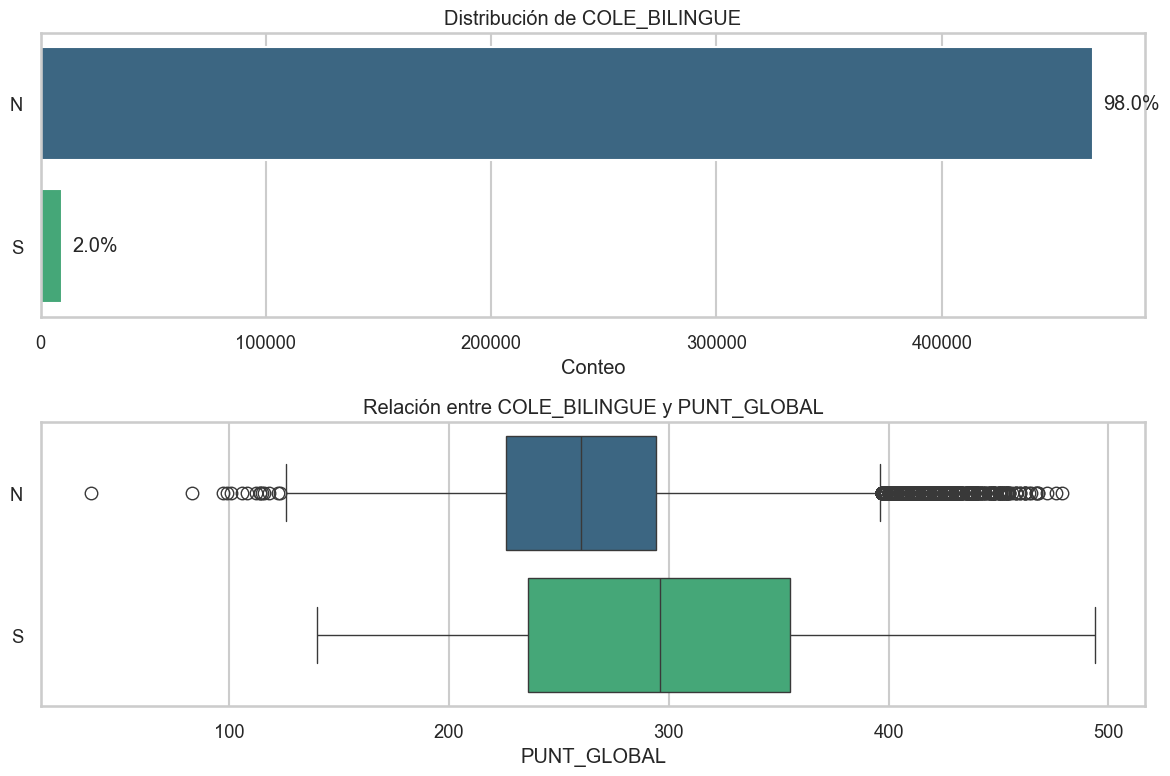

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


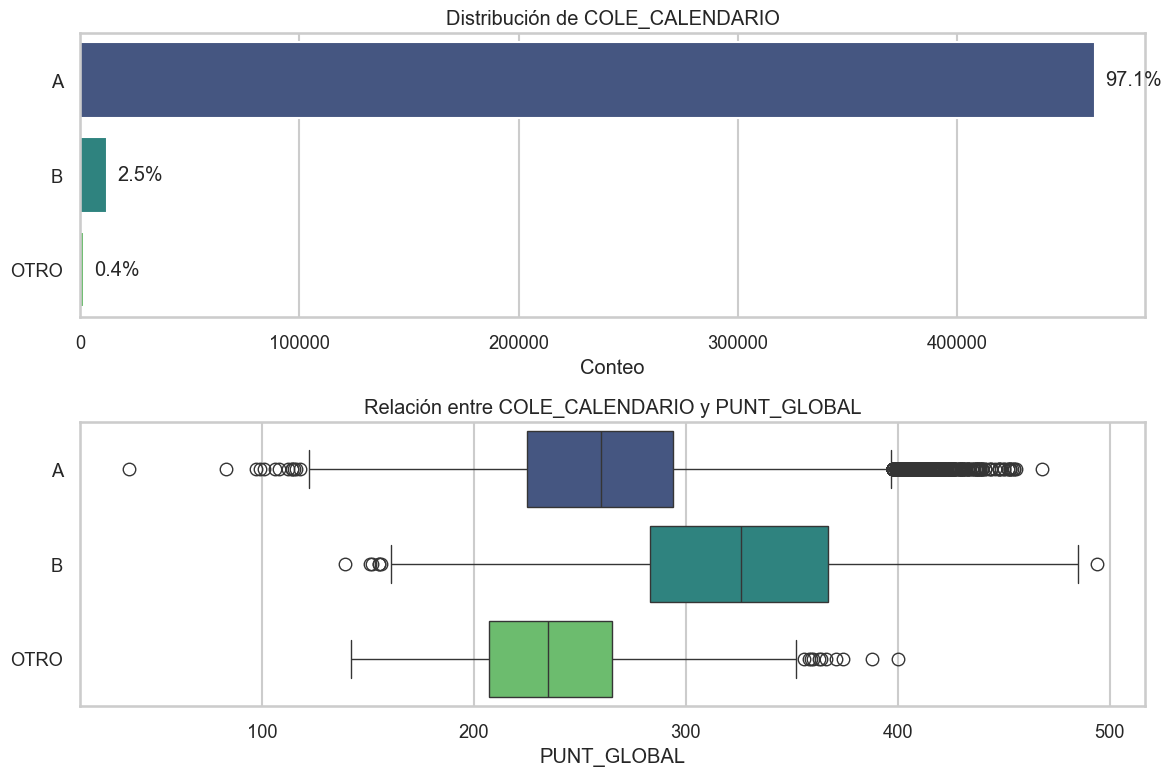

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


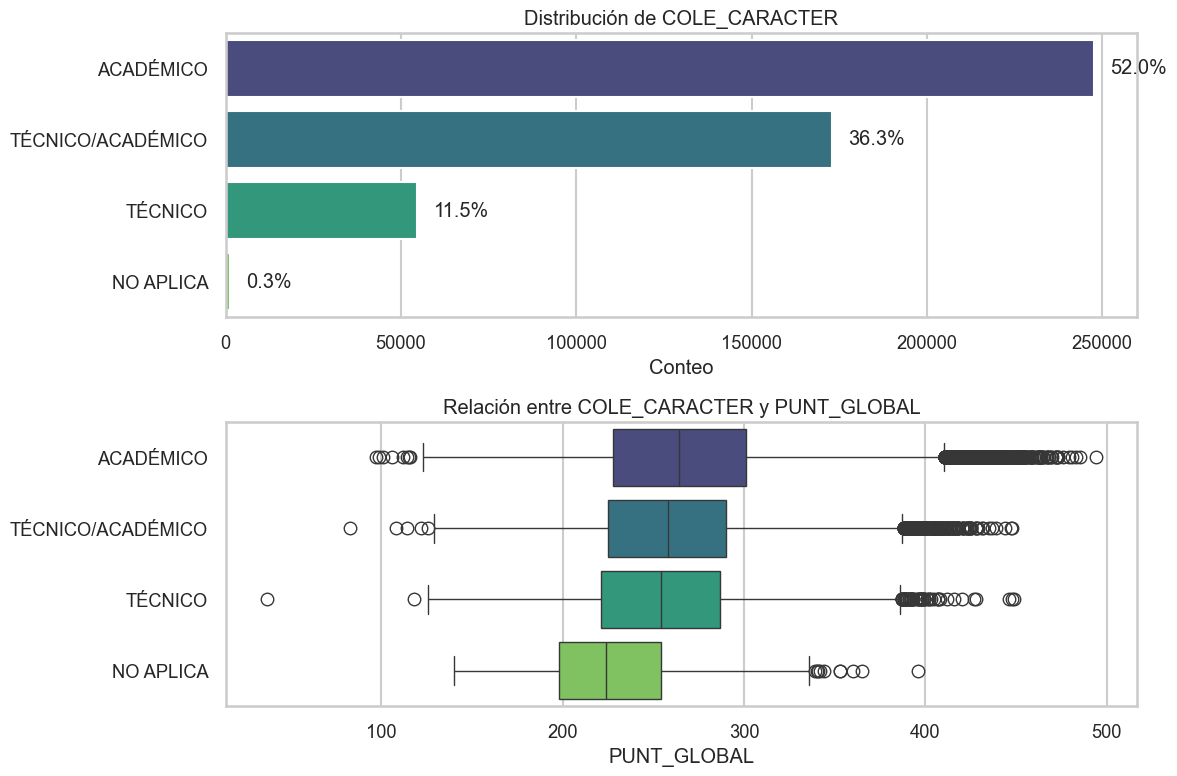

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


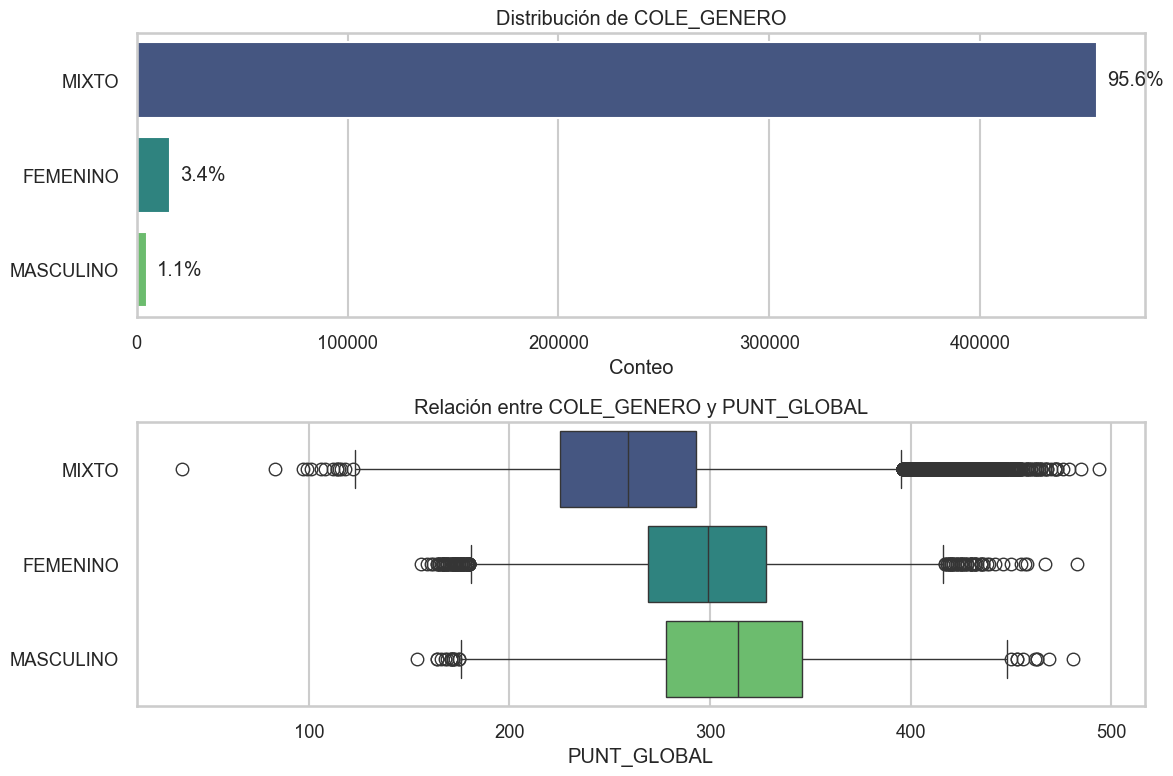

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


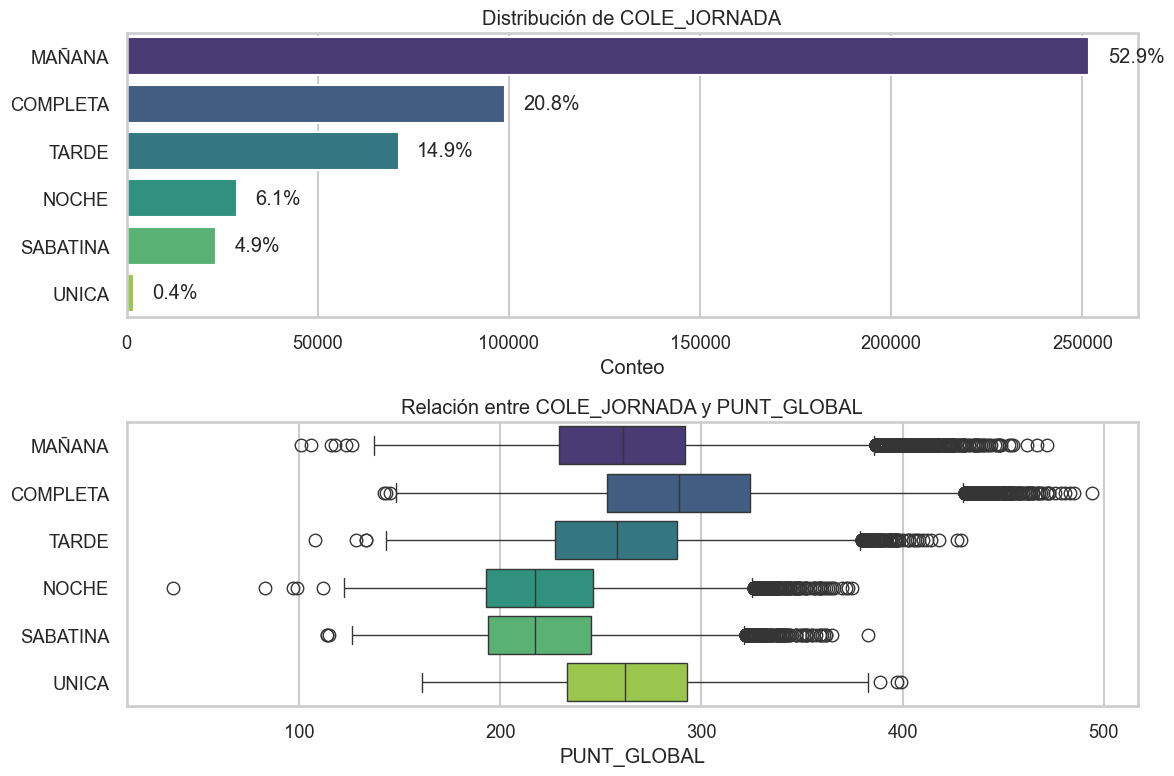

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


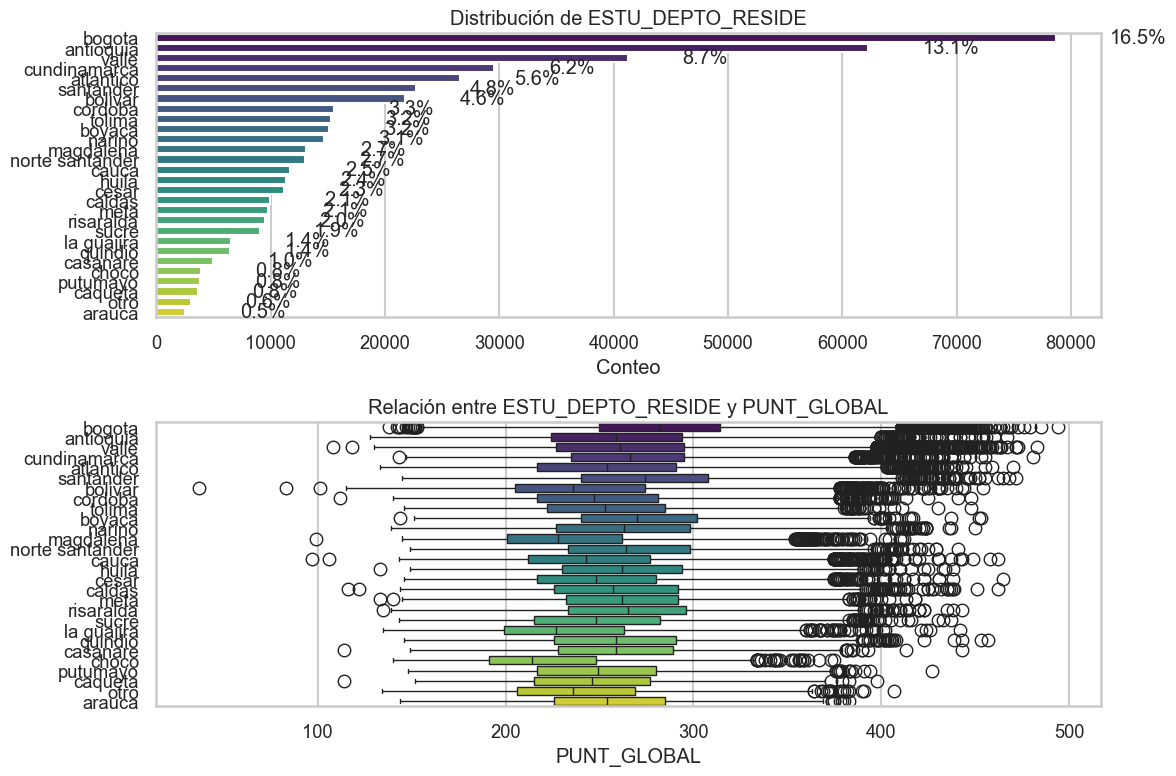

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


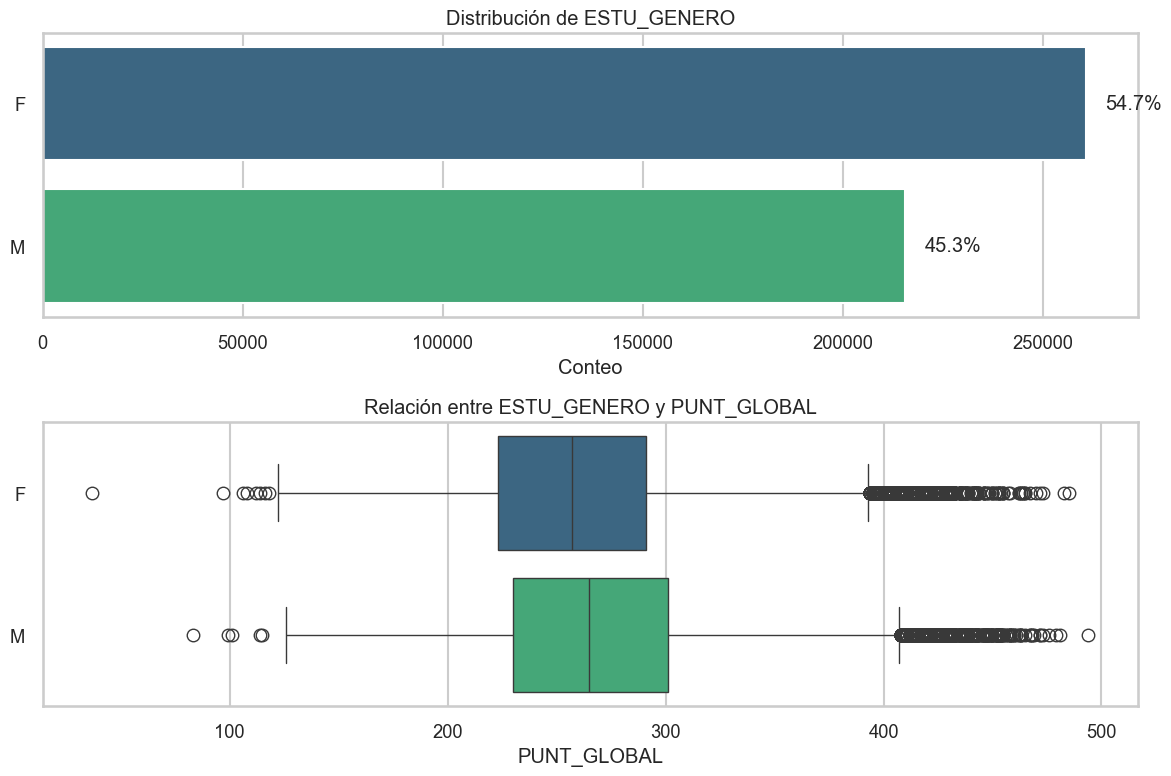

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


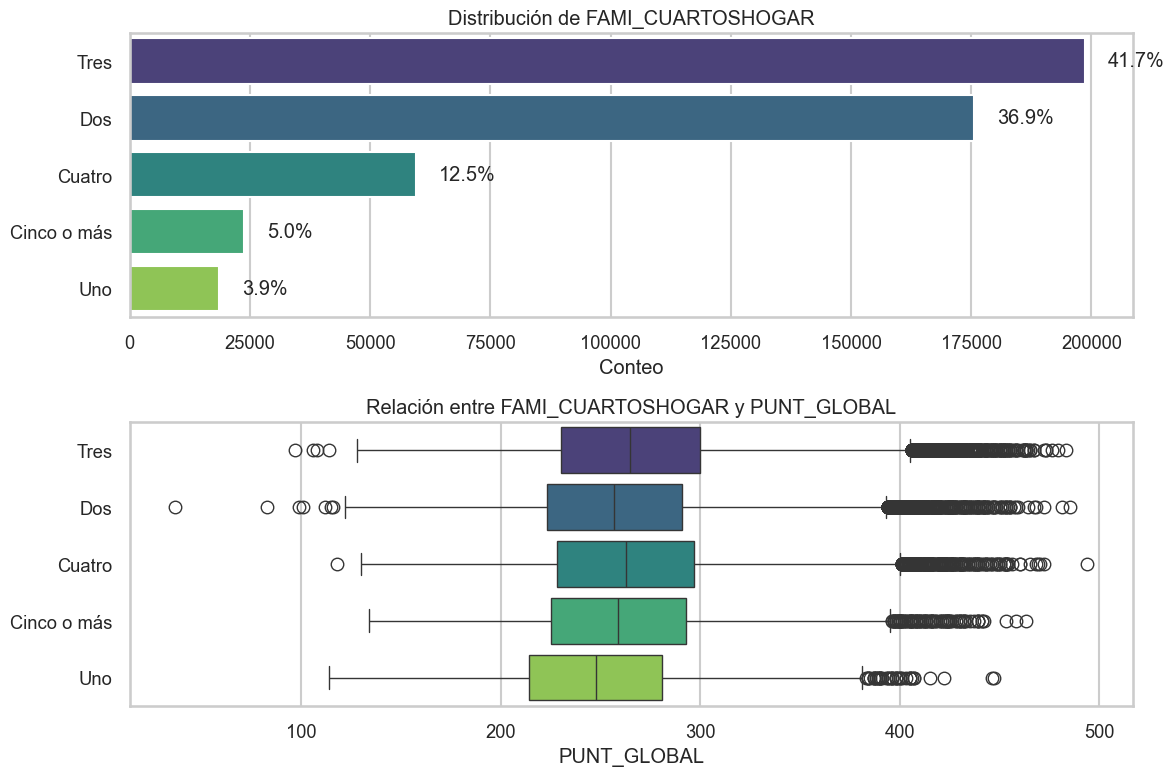

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


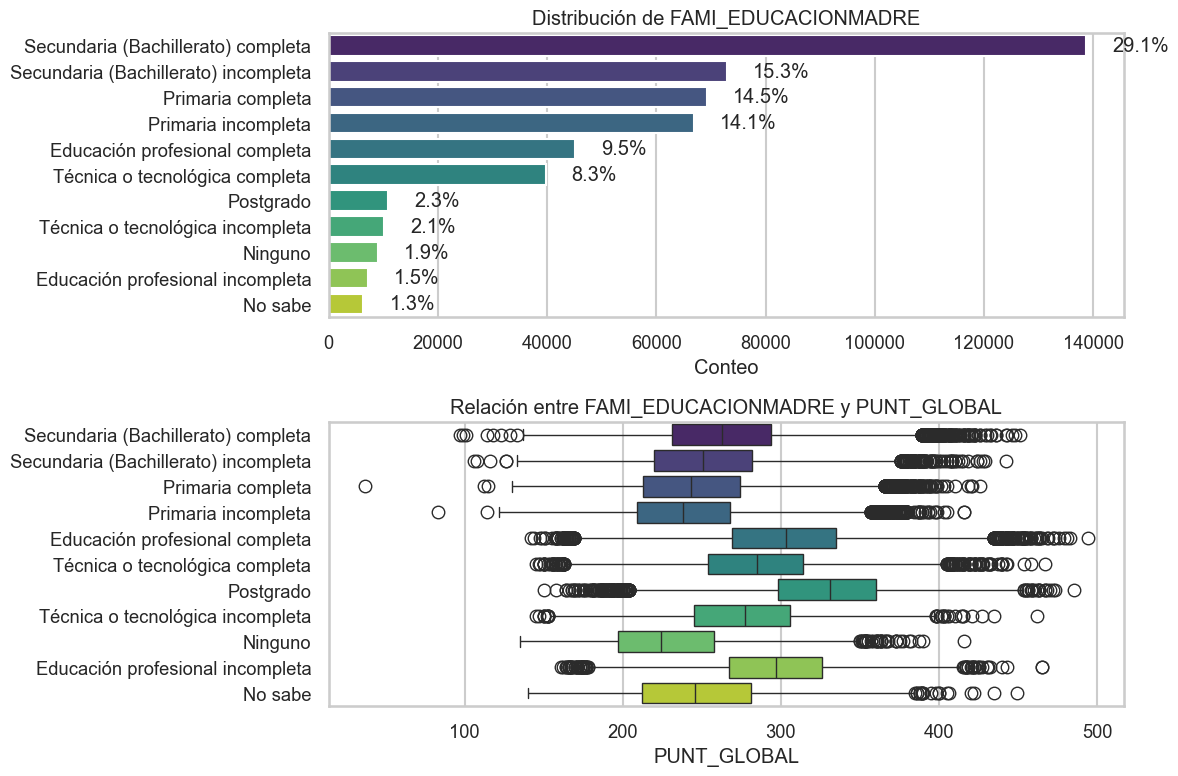

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


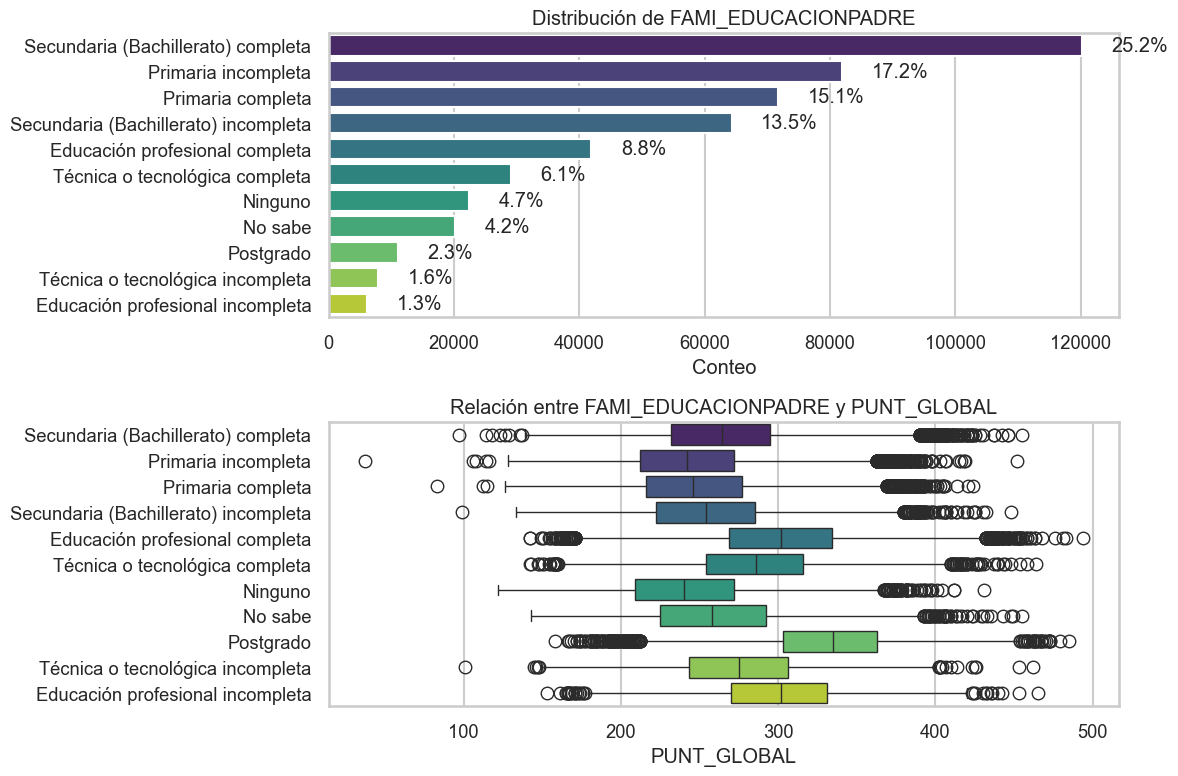

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


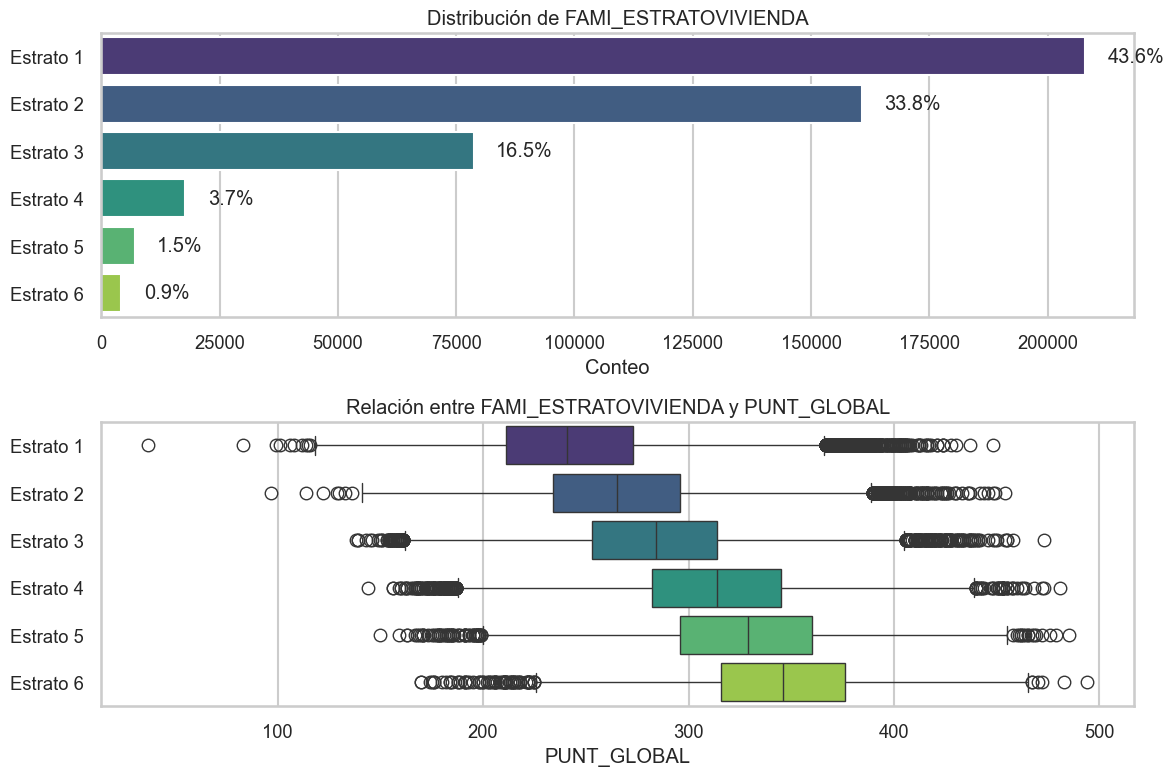

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


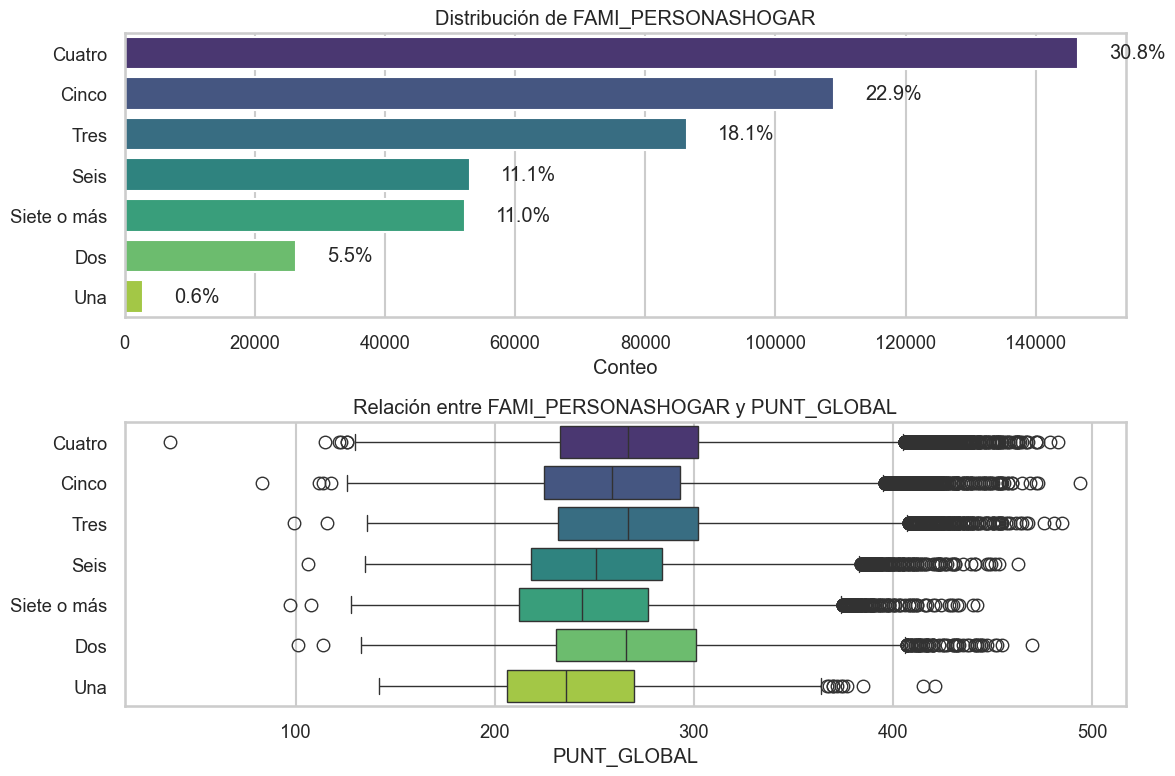

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


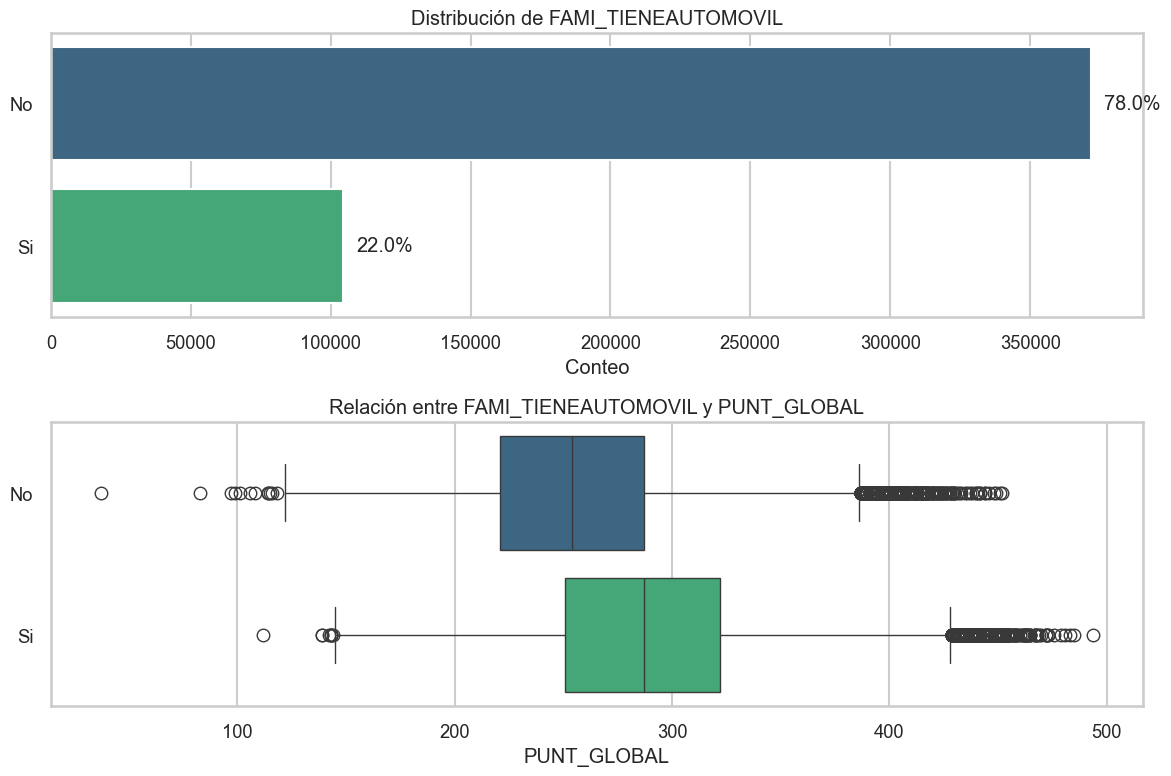

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


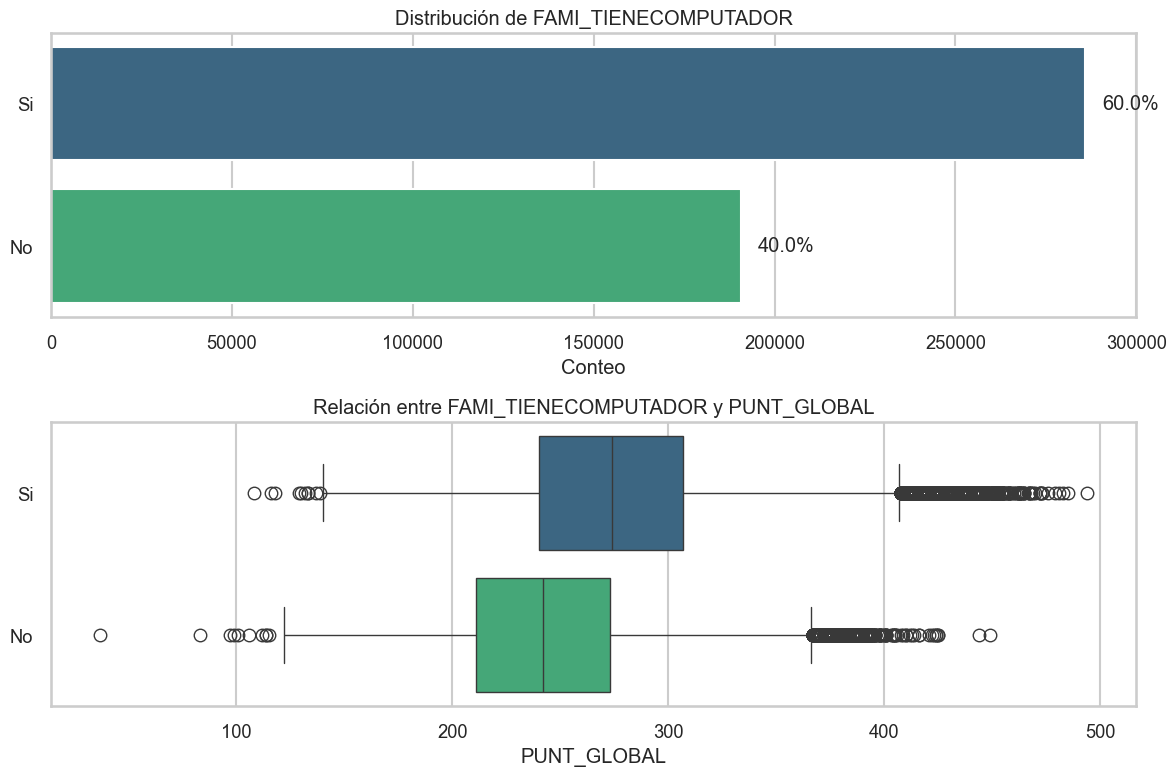

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


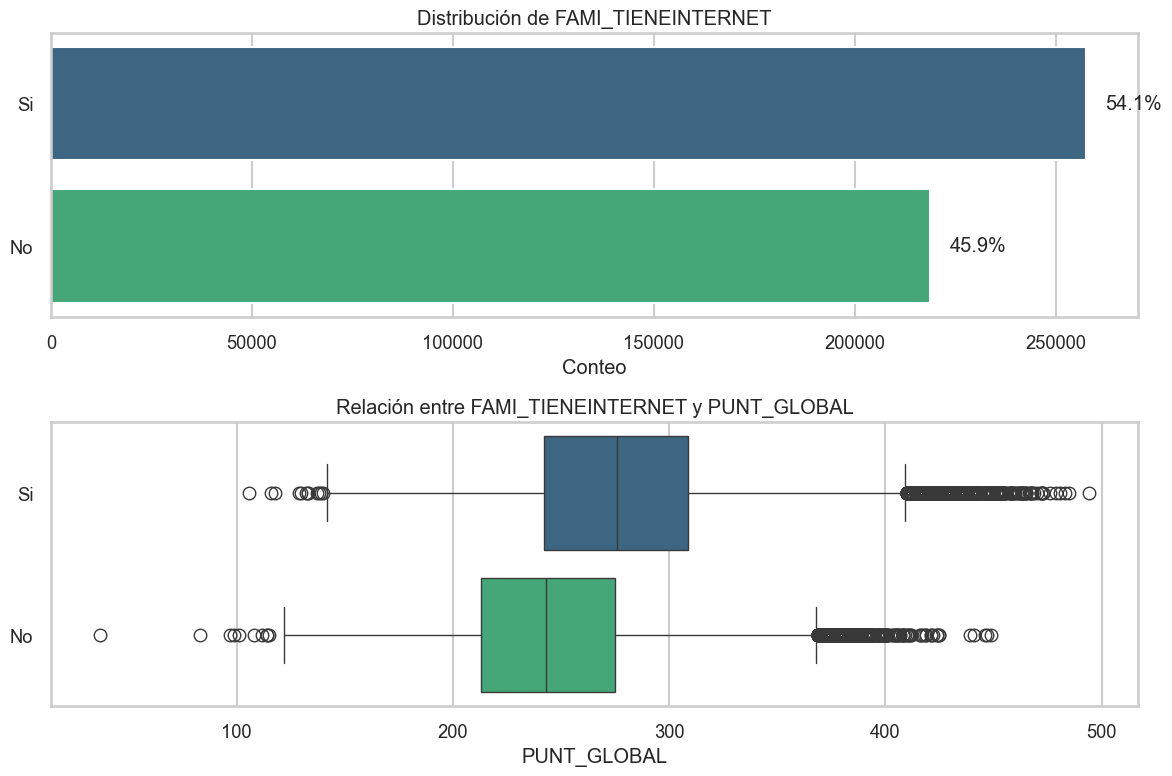

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(
C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3410277053.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.boxplot(


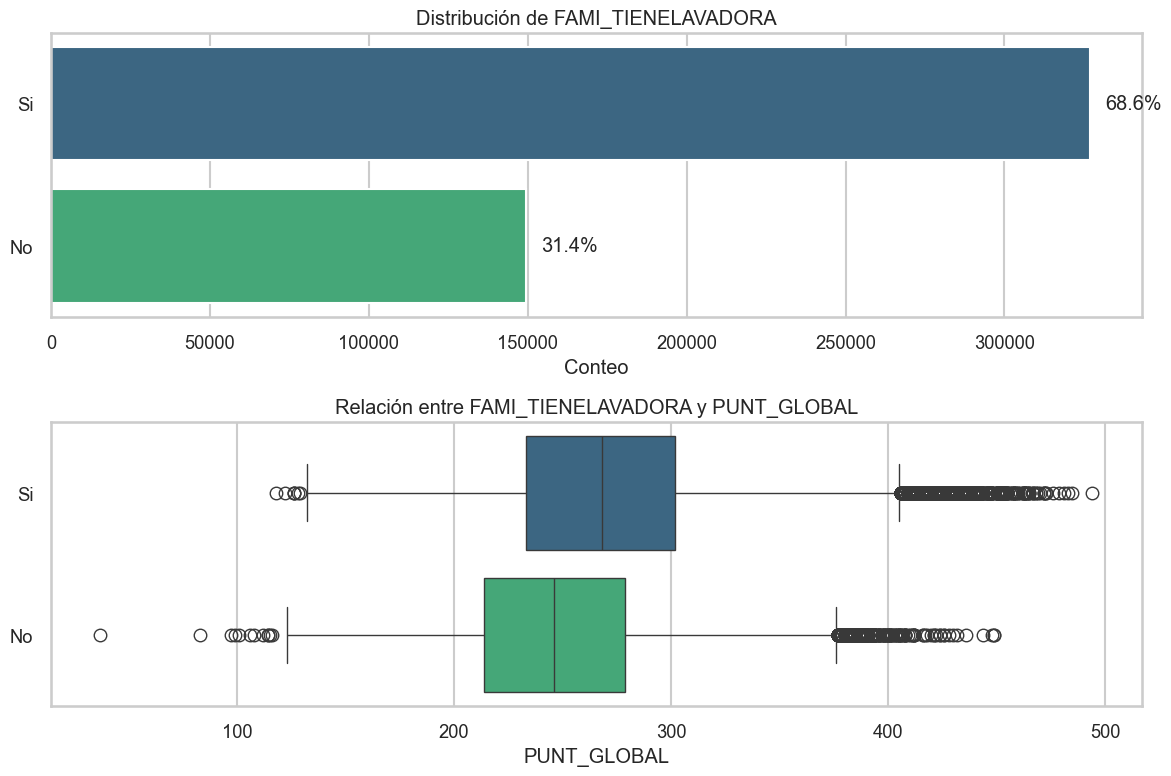

In [ ]:
df = df_model.copy()
categorical_cols = [
    'COLE_BILINGUE', 'COLE_CALENDARIO', 'COLE_CARACTER', 'COLE_GENERO',
    'COLE_JORNADA', 'ESTU_DEPTO_RESIDE', 'ESTU_GENERO',
    'FAMI_CUARTOSHOGAR', 'FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE',
    'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR', 'FAMI_TIENEAUTOMOVIL',
    'FAMI_TIENECOMPUTADOR', 'FAMI_TIENEINTERNET', 'FAMI_TIENELAVADORA'
]
target_variable = 'PUNT_GLOBAL'

def plot_categorical_distribution(df, col, target):
    order = df[col].value_counts().index
    palette_list = sns.color_palette('viridis', n_colors=len(order))

    plt.figure(figsize=(12, 8))

    # ---- Barras ----
    plt.subplot(2, 1, 1)
    ax1 = sns.countplot(
        y=col,
        data=df,
        order=order,
        palette=palette_list
    )
    plt.title(f'Distribución de {col}')
    plt.xlabel('Conteo')
    plt.ylabel('')
    total = len(df)
    for p in ax1.patches:
        pct = 100 * p.get_width() / total
        ax1.text(
            p.get_width() + total * 0.01,
            p.get_y() + p.get_height() / 2,
            f'{pct:.1f}%', va='center'
        )

    # ---- Boxplot ----
    plt.subplot(2, 1, 2)
    ax2 = sns.boxplot(
        y=col,
        x=target,
        data=df,
        order=order,
        palette=palette_list
    )
    plt.title(f'Relación entre {col} y {target}')
    plt.xlabel(target)
    plt.ylabel('')

    plt.tight_layout()
    plt.show()

# Generar gráficos
for col in categorical_cols:
    plot_categorical_distribution(df, col, target_variable)


In [ ]:
# --- Filtrar categorías a eliminar ---
df = df[~df['COLE_JORNADA'].eq('UNICA')]
df = df[~df['COLE_CALENDARIO'].eq('OTRO')]
df = df[~df['COLE_CARACTER'].eq('NO APLICA')]

print("Después del filtrado:")
print("COLE_JORNADA:", df['COLE_JORNADA'].value_counts().index.tolist())
print("COLE_CALENDARIO:", df['COLE_CALENDARIO'].value_counts().index.tolist())
print("COLE_CARACTER:", df['COLE_CARACTER'].value_counts().index.tolist())

Después del filtrado:
COLE_JORNADA: ['MAÑANA', 'COMPLETA', 'TARDE', 'NOCHE', 'SABATINA']
COLE_CALENDARIO: ['A', 'B']
COLE_CARACTER: ['ACADÉMICO', 'TÉCNICO/ACADÉMICO', 'TÉCNICO']


In [ ]:
from scipy.stats import ttest_ind

fem = df.loc[df['ESTU_GENERO']=='F', 'PUNT_GLOBAL']
masc = df.loc[df['ESTU_GENERO']=='M', 'PUNT_GLOBAL']
t_stat, p_val = ttest_ind(fem, masc, equal_var=False)
print(f"t = {t_stat:.2f}, p = {p_val:.3f}")
print("Media F:", fem.mean(), "– Media M:", masc.mean())


t = -54.66, p = 0.000
Media F: 258.86449801529676 – Media M: 266.60891474321716


In [ ]:
fem = df.loc[df['ESTU_GENERO']=='F', 'PUNT_GLOBAL']
masc = df.loc[df['ESTU_GENERO']=='M', 'PUNT_GLOBAL']

n_f, n_m   = len(fem), len(masc)
sd_f, sd_m = fem.std(ddof=1), masc.std(ddof=1)

pooled_sd = np.sqrt(((n_f-1)*sd_f**2 + (n_m-1)*sd_m**2) / (n_f+n_m-2))
cohen_d   = (masc.mean() - fem.mean()) / pooled_sd

print(f"Cohen's d = {cohen_d:.2f}")


Cohen's d = 0.16


Se podria eliminar genero si se busca simplificar el modelo ya que tiene un efecto muy pequeño

In [ ]:
# df.to_csv('datos_limpios_2.csv', index=False, encoding='utf-8')

### Categorías

In [ ]:
# df = pd.read_csv("datos_limpios_2.csv")

In [ ]:
# cortes

bins   = [df['PUNT_GLOBAL'].min() - 1, 230, 300, df['PUNT_GLOBAL'].max() + 1]
labels = ['Bajo', 'Medio', 'Alto']

df['PUNT_GLOBAL_CAT'] = pd.cut(
    df['PUNT_GLOBAL'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(df['PUNT_GLOBAL_CAT'].value_counts())


PUNT_GLOBAL_CAT
Medio    237319
Bajo     130712
Alto     103526
Name: count, dtype: int64


PUNT_GLOBAL_CAT
Medio    237319
Bajo     130712
Alto     103526
Name: count, dtype: int64


C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3286299214.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='PUNT_GLOBAL_CAT', data=df, order=order, palette=palette)


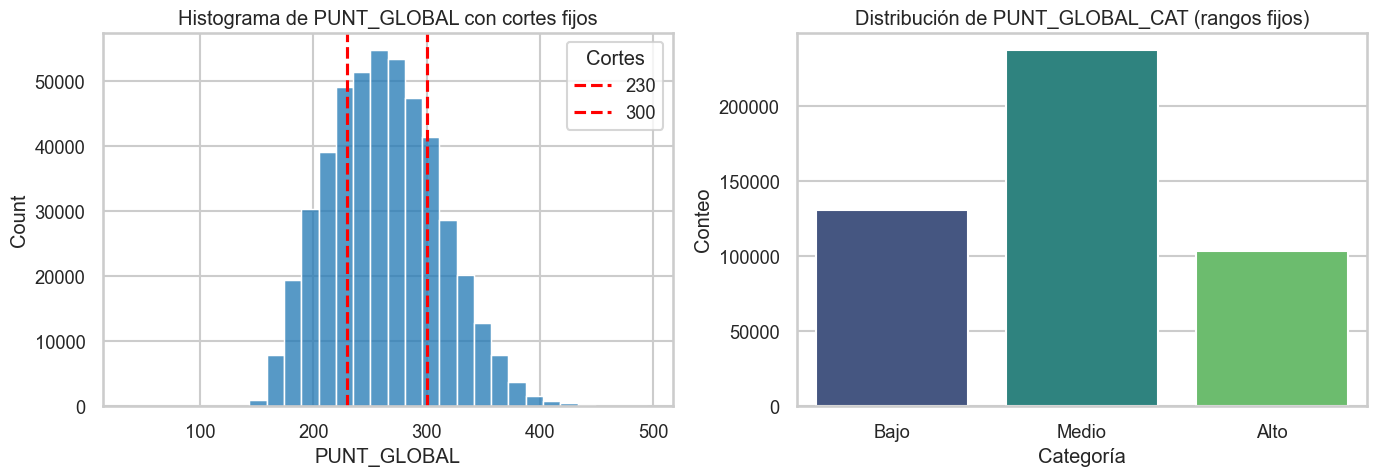

In [ ]:

bins   = [df['PUNT_GLOBAL'].min() - 1, 230, 300, df['PUNT_GLOBAL'].max() + 1]
labels = ['Bajo', 'Medio', 'Alto']
df['PUNT_GLOBAL_CAT'] = pd.cut(
    df['PUNT_GLOBAL'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

print(df['PUNT_GLOBAL_CAT'].value_counts())
cut_offs = [230, 300]
plt.figure(figsize=(14, 5))

# — Histograma con cortes —
plt.subplot(1, 2, 1)
sns.histplot(df['PUNT_GLOBAL'], bins=30, kde=False)
for c in cut_offs:
    plt.axvline(c, color='red', linestyle='--', label=f'{c}')
plt.title('Histograma de PUNT_GLOBAL con cortes fijos')
plt.xlabel('PUNT_GLOBAL')
plt.legend(title='Cortes')

# — Conteo por categoría —
plt.subplot(1, 2, 2)
order = ['Bajo', 'Medio', 'Alto']
palette = sns.color_palette('viridis', n_colors=3)
sns.countplot(x='PUNT_GLOBAL_CAT', data=df, order=order, palette=palette)
plt.title('Distribución de PUNT_GLOBAL_CAT (rangos fijos)')
plt.xlabel('Categoría')
plt.ylabel('Conteo')

plt.tight_layout()
plt.show()


In [ ]:
# Cortes con terciles
df['PUNT_GLOBAL_CAT'] = pd.qcut(
    df['PUNT_GLOBAL'],
    q=3,
    labels=['Bajo', 'Medio', 'Alto']
)

print(df['PUNT_GLOBAL_CAT'].value_counts())


PUNT_GLOBAL_CAT
Bajo     159976
Medio    156497
Alto     155084
Name: count, dtype: int64


C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\488506260.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='PUNT_GLOBAL_CAT', data=df, order=order, palette=palette)


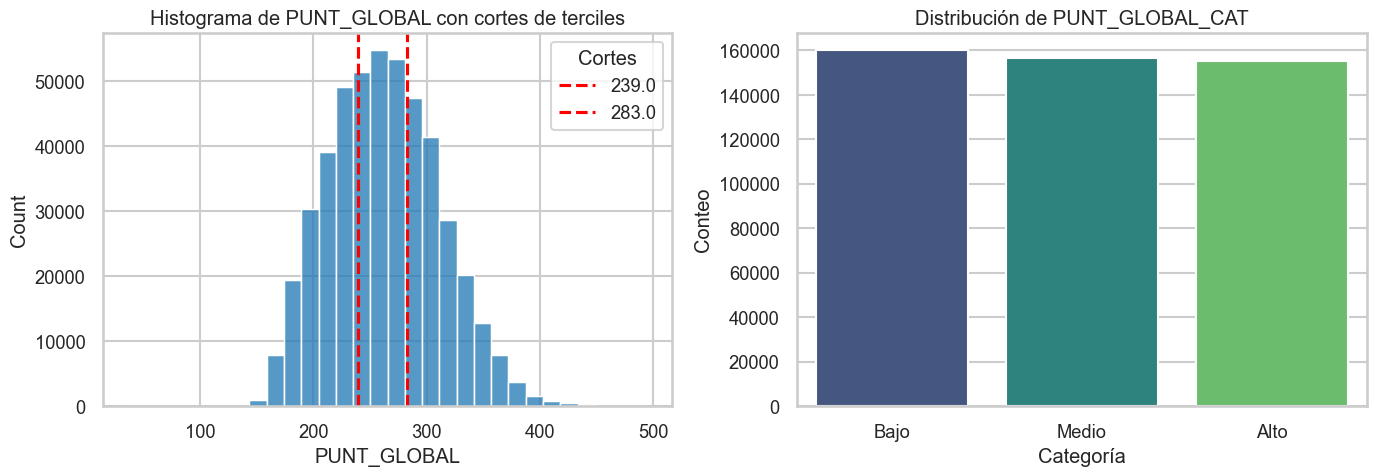

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculo de los cuantiles 1/3 y 2/3
quantiles = df['PUNT_GLOBAL'].quantile([1/3, 2/3]).values
plt.figure(figsize=(14, 5))

# Histograma con cortes
plt.subplot(1, 2, 1)
sns.histplot(df['PUNT_GLOBAL'], bins=30, kde=False)
for q in quantiles:
    plt.axvline(q, color='red', linestyle='--', label=f'{q:.1f}')
plt.title('Histograma de PUNT_GLOBAL con cortes de terciles')
plt.xlabel('PUNT_GLOBAL')
plt.legend(title='Cortes')

# Conteo por categoría
plt.subplot(1, 2, 2)
order = ['Bajo', 'Medio', 'Alto']
palette = sns.color_palette('viridis', n_colors=3)
sns.countplot(x='PUNT_GLOBAL_CAT', data=df, order=order, palette=palette)
plt.title('Distribución de PUNT_GLOBAL_CAT')
plt.xlabel('Categoría')
plt.ylabel('Conteo')

plt.tight_layout()
plt.show()


In [ ]:
df.PUNT_GLOBAL_CAT.value_counts()

PUNT_GLOBAL_CAT
Bajo     159976
Medio    156497
Alto     155084
Name: count, dtype: int64

In [ ]:
df = df.drop(columns='PUNT_GLOBAL')
df.nunique().sort_values()

COLE_BILINGUE            2
COLE_CALENDARIO          2
ESTU_GENERO              2
FAMI_TIENELAVADORA       2
FAMI_TIENEAUTOMOVIL      2
FAMI_TIENECOMPUTADOR     2
FAMI_TIENEINTERNET       2
COLE_CARACTER            3
COLE_GENERO              3
PUNT_GLOBAL_CAT          3
FAMI_CUARTOSHOGAR        5
COLE_JORNADA             5
FAMI_ESTRATOVIVIENDA     6
FAMI_PERSONASHOGAR       7
FAMI_EDUCACIONPADRE     11
FAMI_EDUCACIONMADRE     11
EDAD                    19
ESTU_DEPTO_RESIDE       28
dtype: int64

In [ ]:
df.to_csv('datos_limpios_2.csv', index=False, encoding='utf-8')

### Gráficas

In [ ]:
df = pd.read_csv("datos_limpios_2.csv")

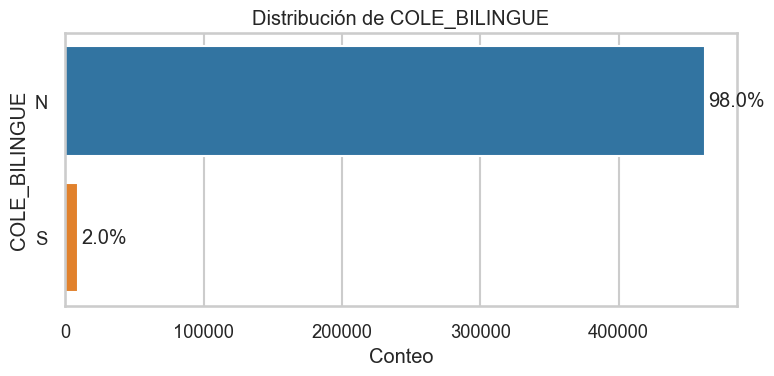

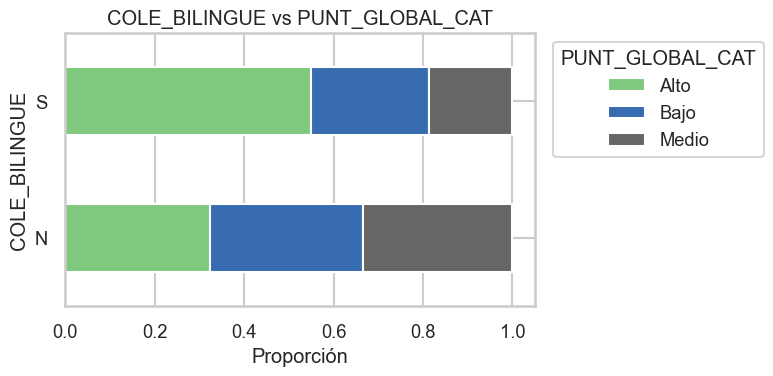

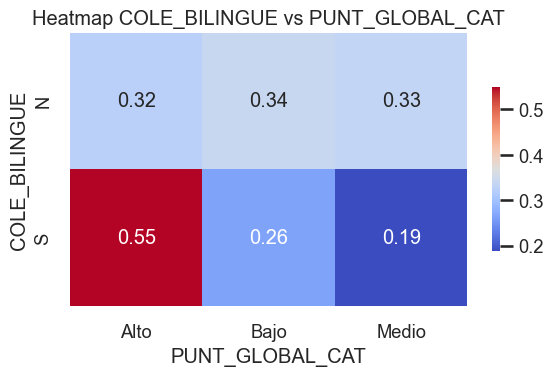

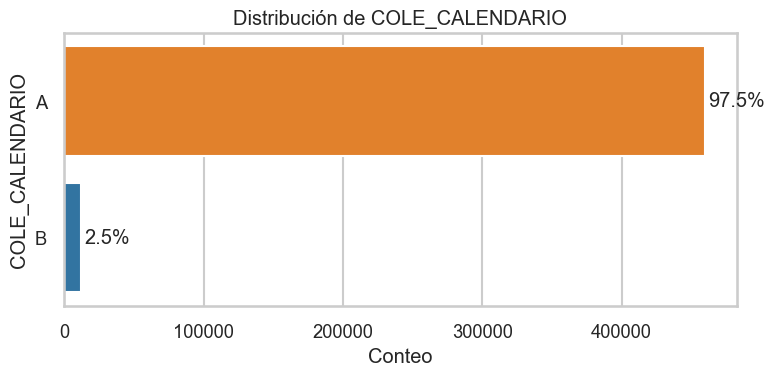

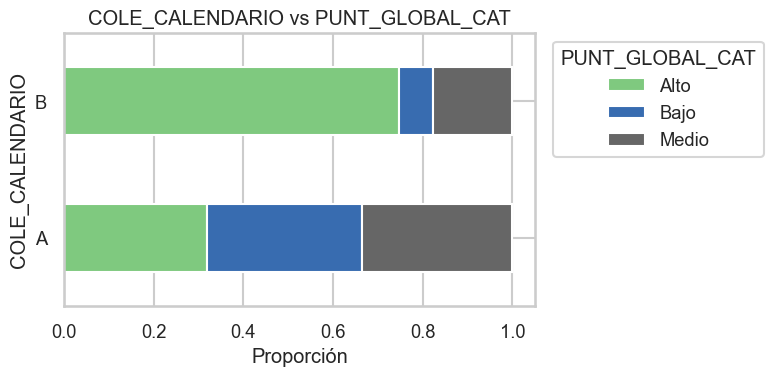

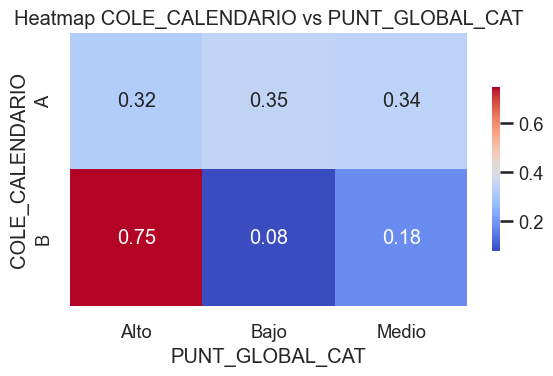

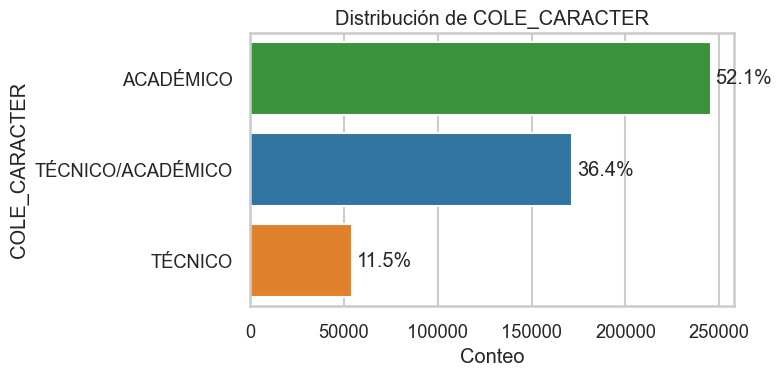

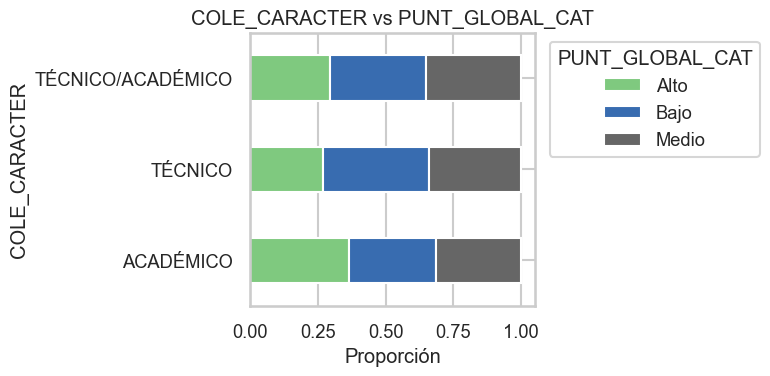

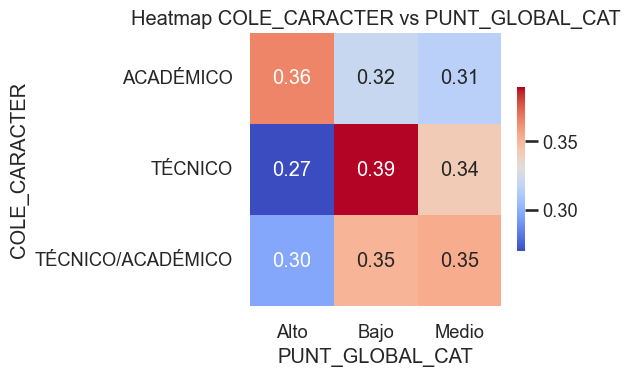

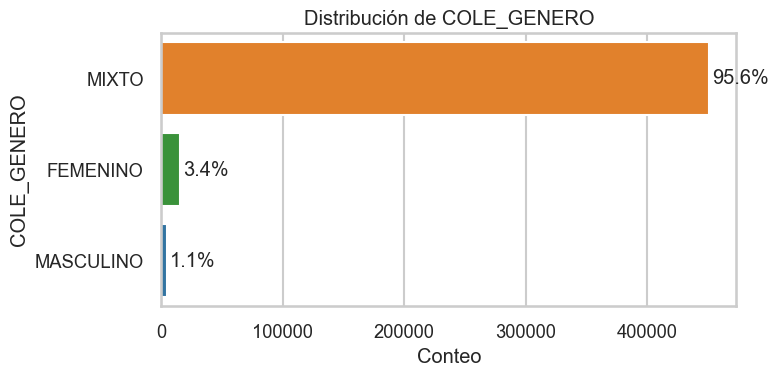

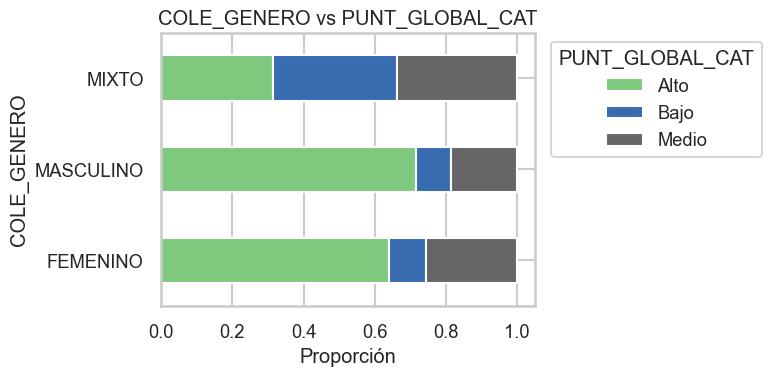

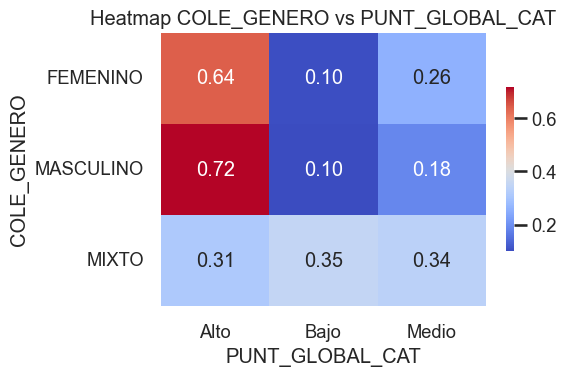

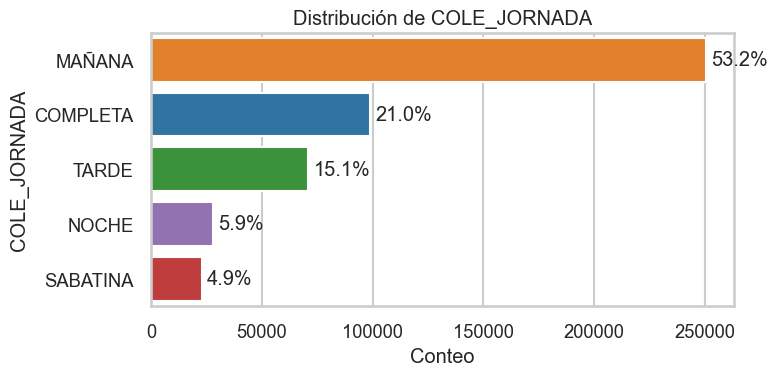

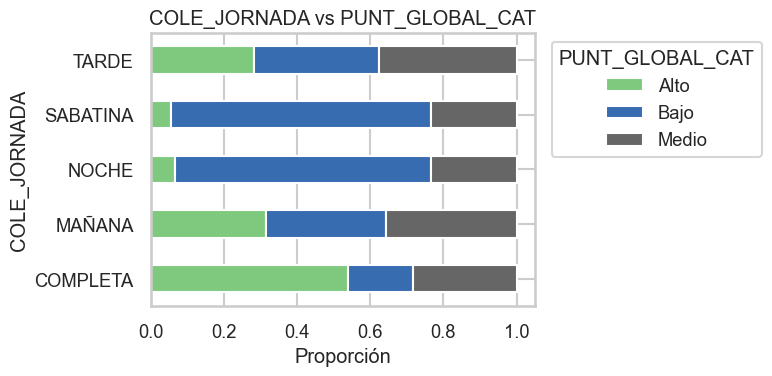

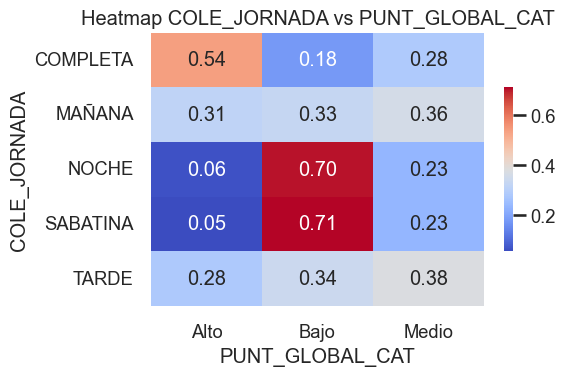

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3057528669.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=45, ha='right')


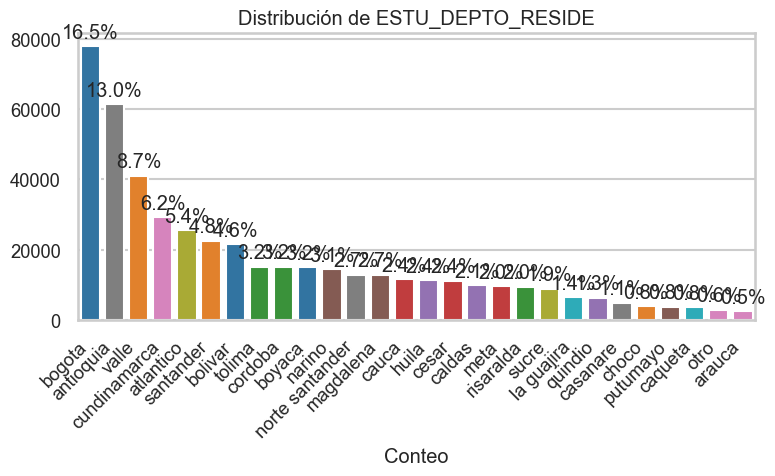

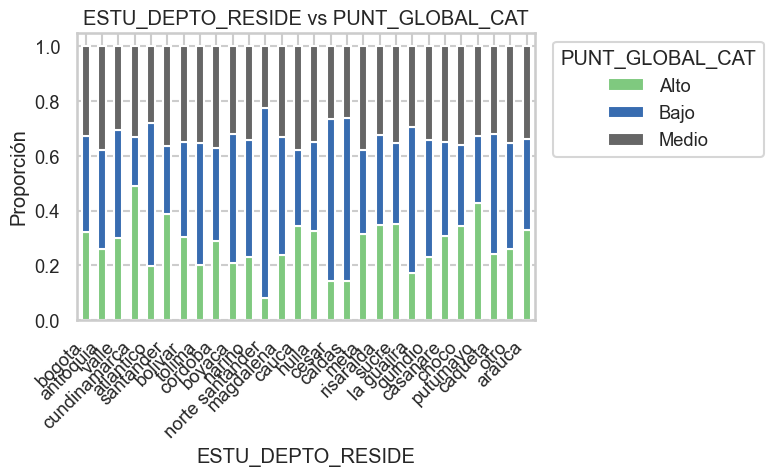

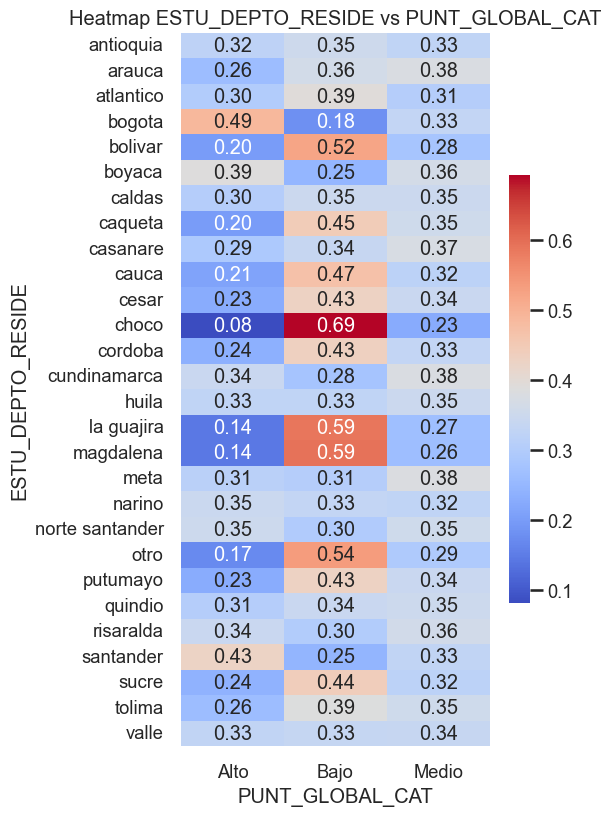

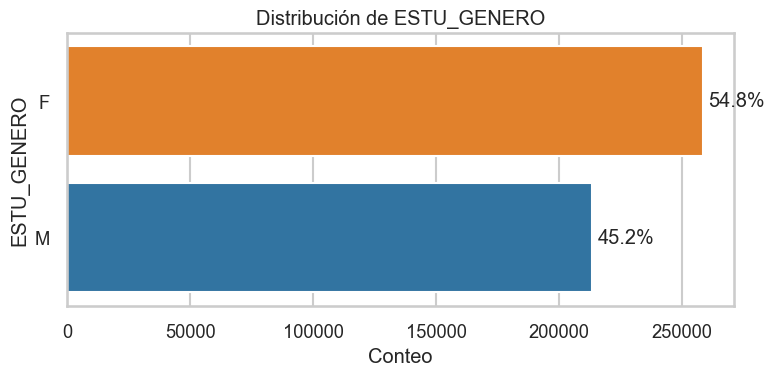

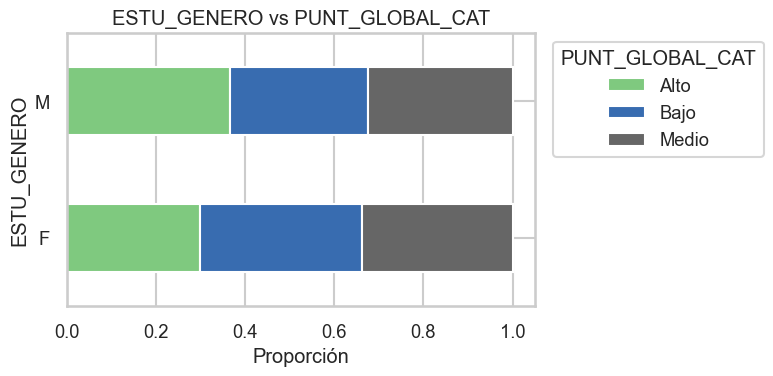

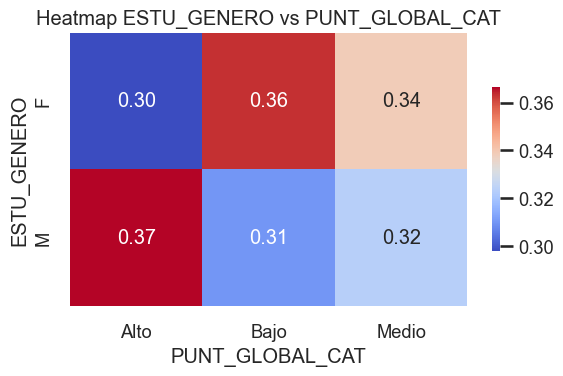

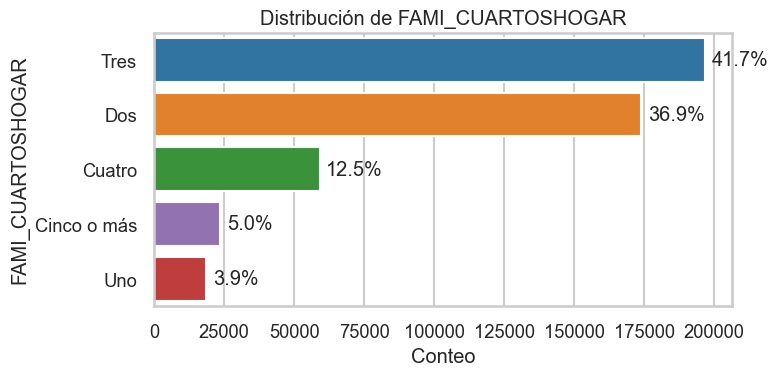

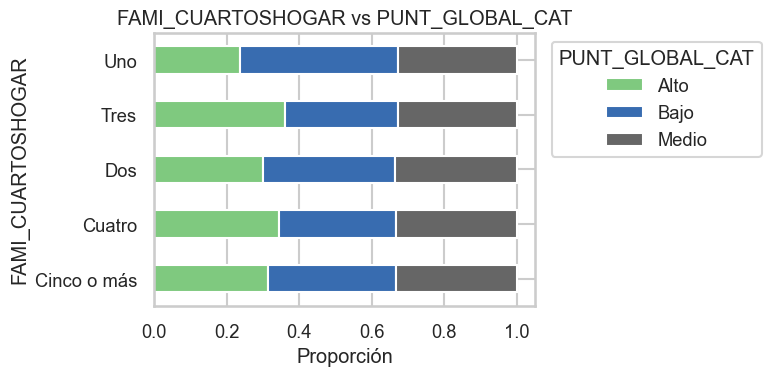

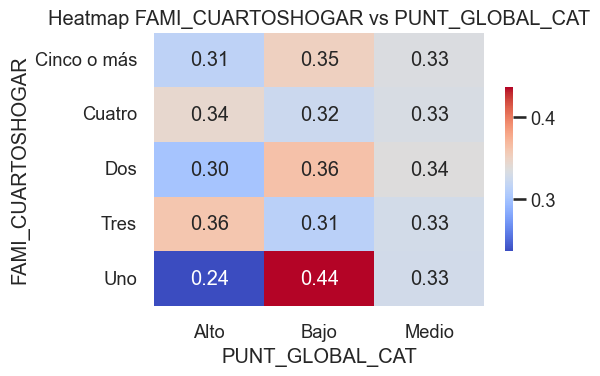

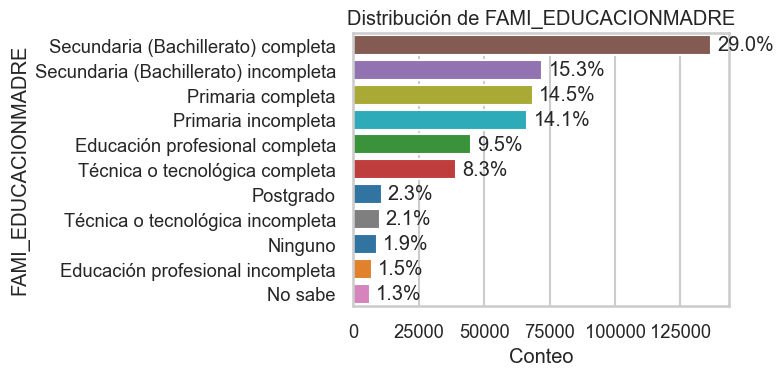

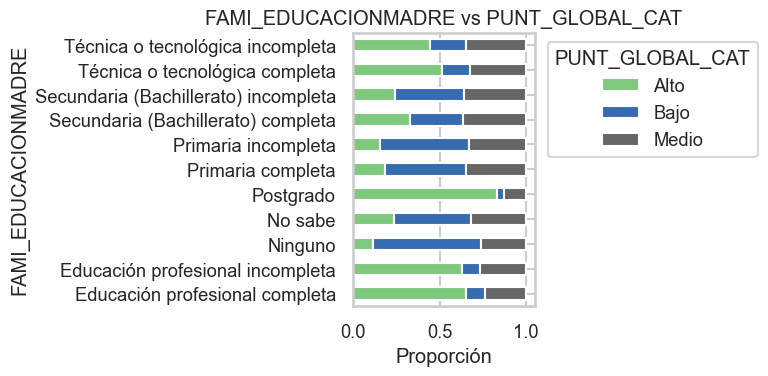

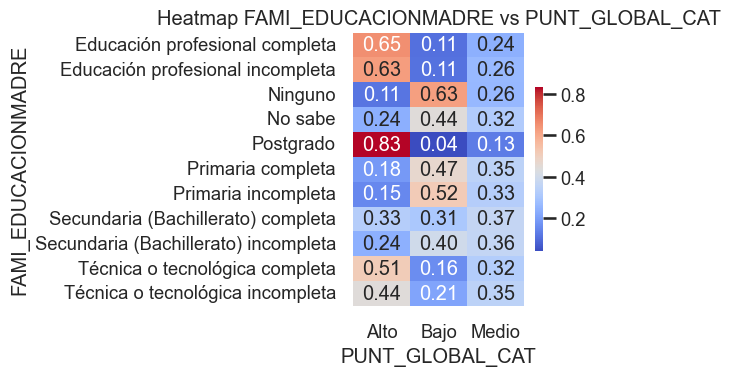

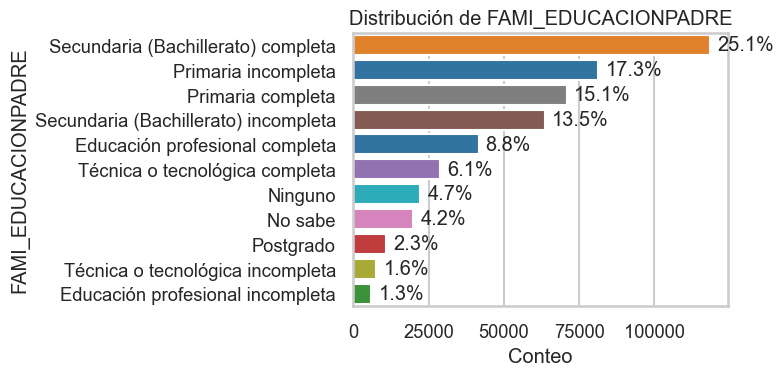

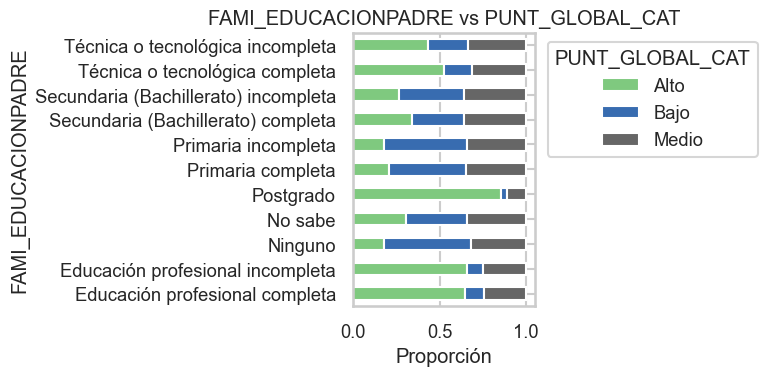

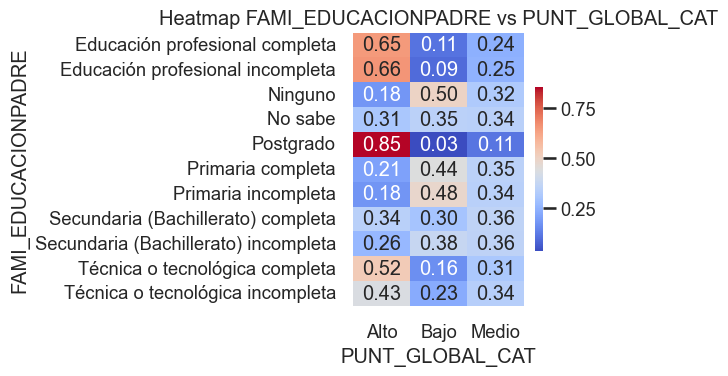

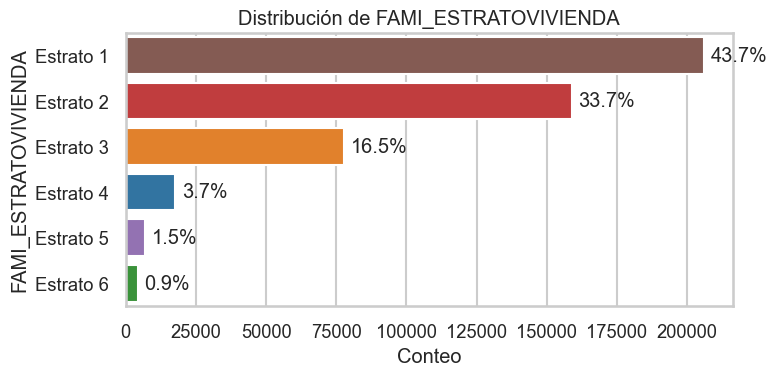

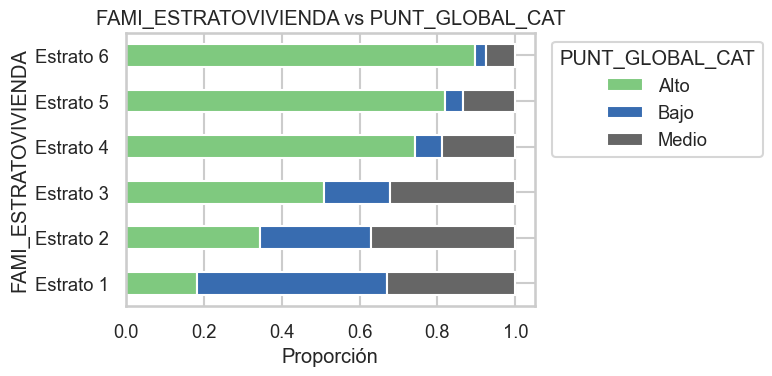

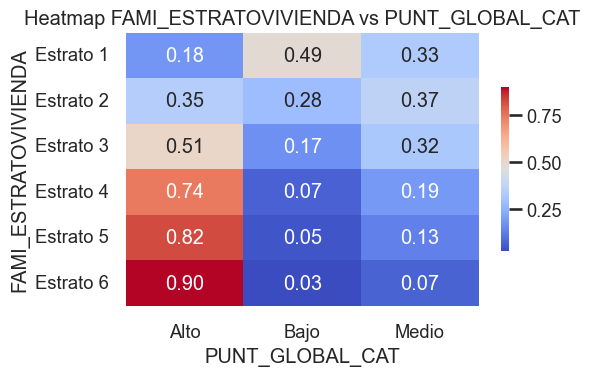

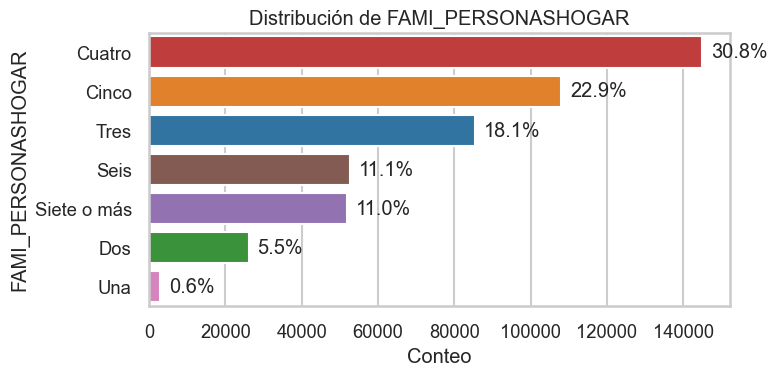

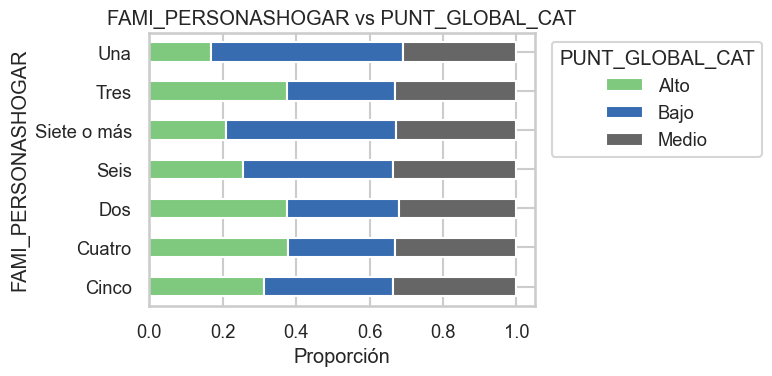

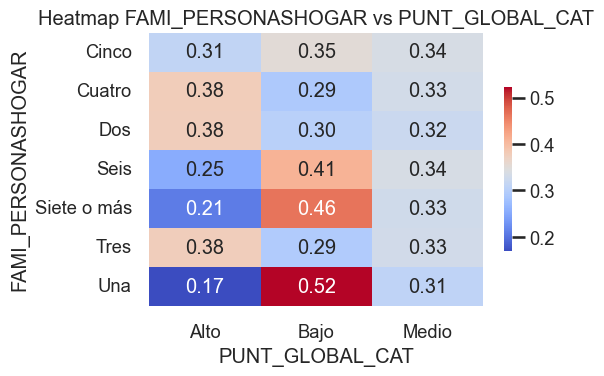

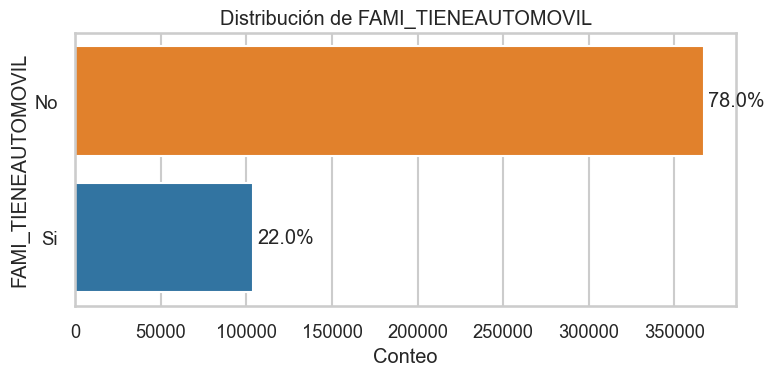

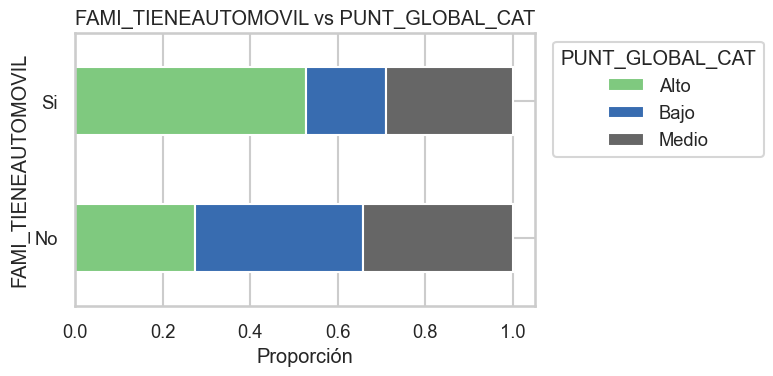

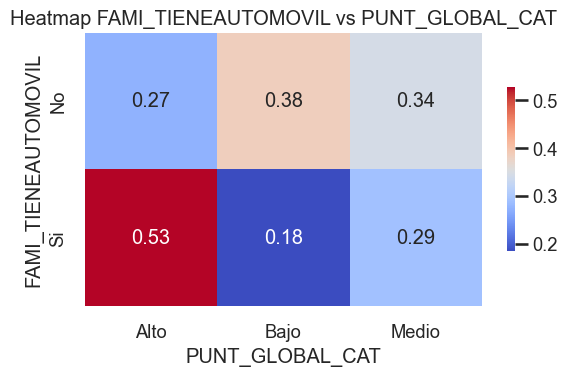

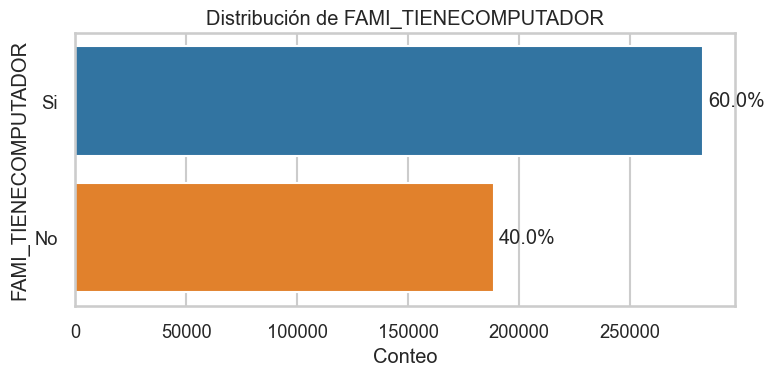

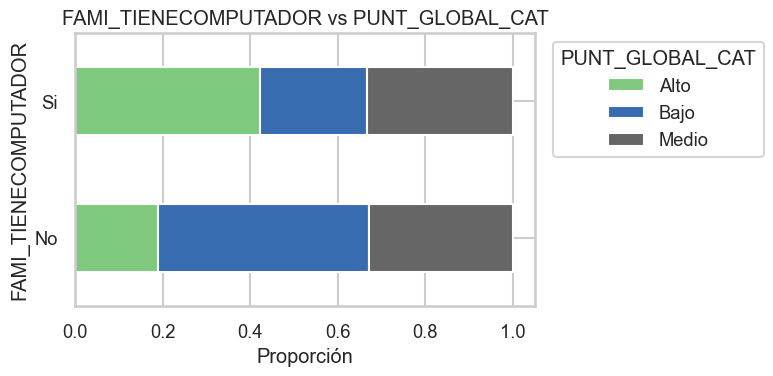

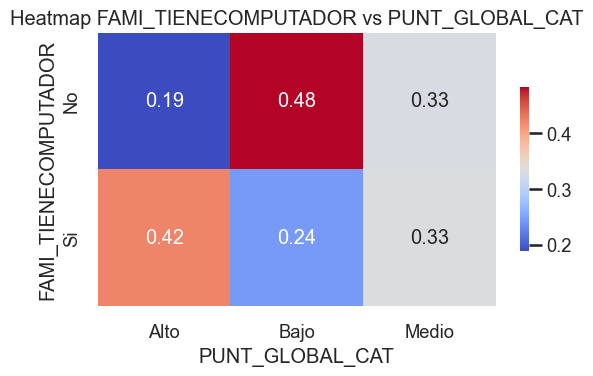

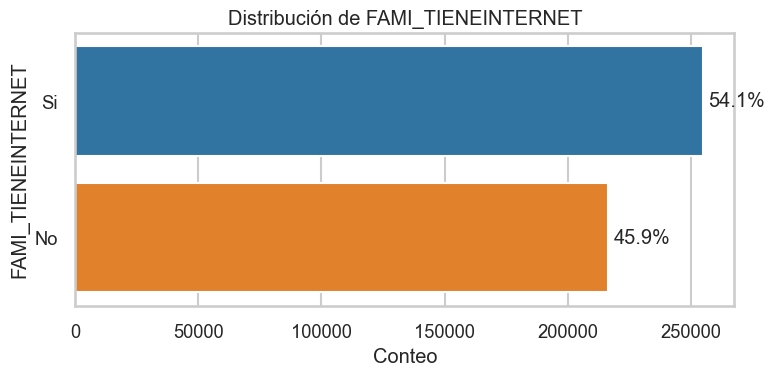

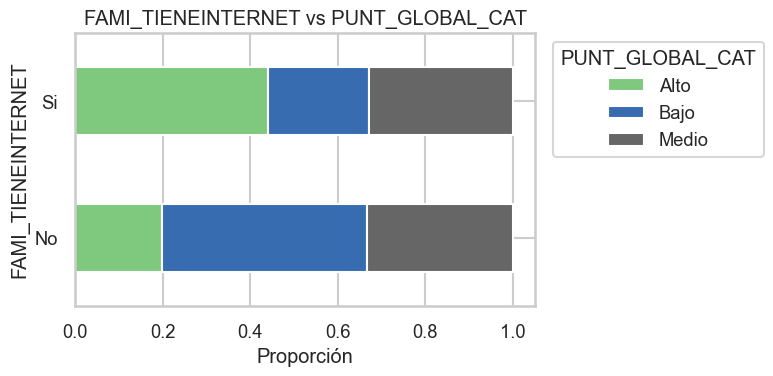

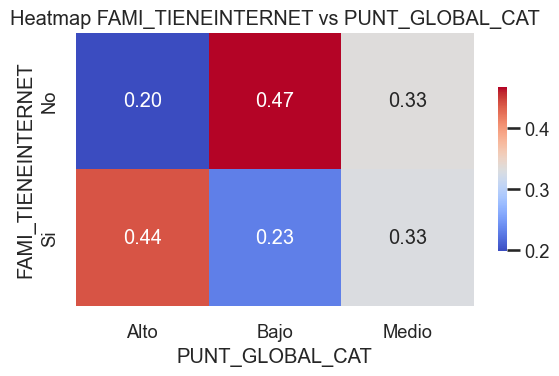

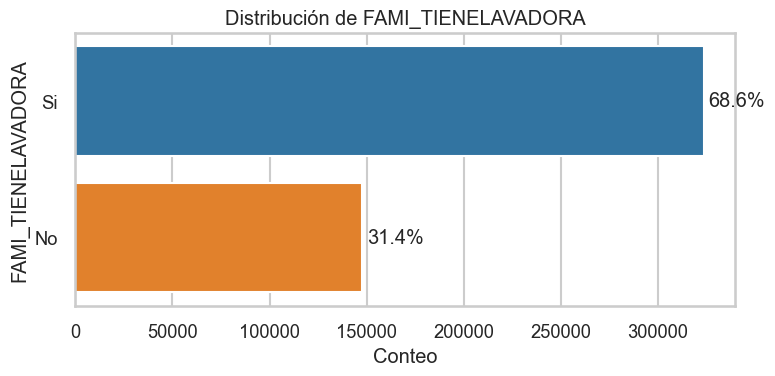

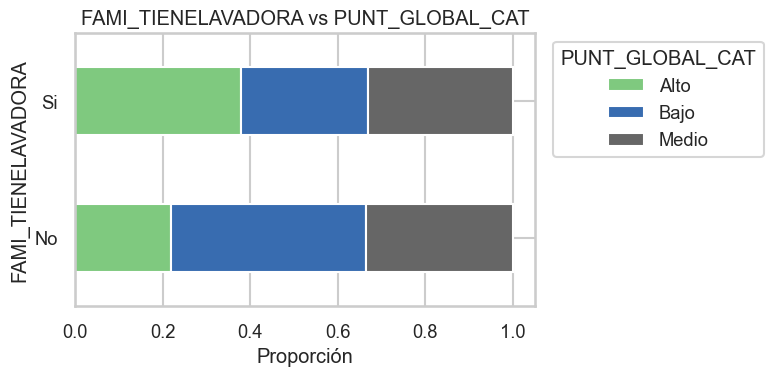

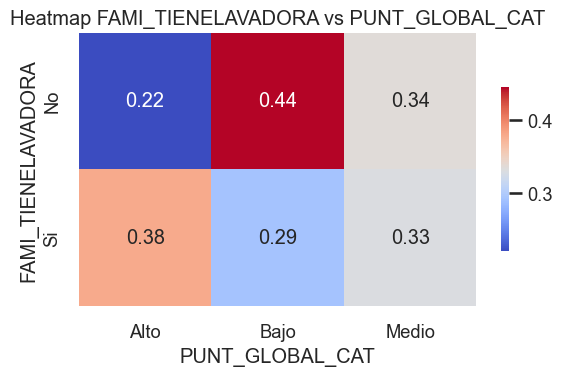


-- Top 20 categorías:
FAMI_TIENEINTERNET_Si                                 0.043494
FAMI_TIENECOMPUTADOR_Si                               0.041298
FAMI_TIENEAUTOMOVIL_Si                                0.027239
COLE_JORNADA_NOCHE                                    0.020487
FAMI_ESTRATOVIVIENDA_Estrato 3                        0.018757
COLE_JORNADA_SABATINA                                 0.017761
FAMI_TIENELAVADORA_Si                                 0.016128
FAMI_EDUCACIONMADRE_Primaria incompleta               0.016091
ESTU_DEPTO_RESIDE_bogota                              0.015387
FAMI_ESTRATOVIVIENDA_Estrato 4                        0.015060
FAMI_EDUCACIONPADRE_Postgrado                         0.014656
FAMI_EDUCACIONPADRE_Primaria incompleta               0.014435
FAMI_EDUCACIONMADRE_Postgrado                         0.013415
COLE_GENERO_MIXTO                                     0.011910
COLE_CALENDARIO_B                                     0.010171
FAMI_EDUCACIONMADRE_Primaria com

In [ ]:
# --- Ajustes globales de estilo y tamaño de texto ---
sns.set_style('whitegrid')
sns.set_context('talk', font_scale=0.8)

cat_cols = [
    'COLE_BILINGUE','COLE_CALENDARIO','COLE_CARACTER','COLE_GENERO',
    'COLE_JORNADA','ESTU_DEPTO_RESIDE','ESTU_GENERO',
    'FAMI_CUARTOSHOGAR','FAMI_EDUCACIONMADRE','FAMI_EDUCACIONPADRE',
    'FAMI_ESTRATOVIVIENDA','FAMI_PERSONASHOGAR',
    'FAMI_TIENEAUTOMOVIL','FAMI_TIENECOMPUTADOR',
    'FAMI_TIENEINTERNET','FAMI_TIENELAVADORA'
]
target = 'PUNT_GLOBAL_CAT'

def graficos_categoricos(columnas):
    cat_cols = columnas
    

    for col in cat_cols:
        order = df[col].value_counts().index
        n_cat = len(order)
        total = len(df)

        # a) Countplot
        fig, ax = plt.subplots(
            figsize=(
                8 if col=='ESTU_DEPTO_RESIDE' else 8,
                5 if col=='ESTU_DEPTO_RESIDE' else max(4, n_cat*0.3)
            )
        )

        if col != 'ESTU_DEPTO_RESIDE':
            # horizontal
            sns.countplot(
                y=col, data=df,
                order=order,
                hue=col,
                palette='tab10',
                dodge=False,
                ax=ax
            )
            # quitar leyenda
            lg = ax.get_legend()
            if lg: lg.remove()
            ax.set_xlabel('Conteo')
            ax.set_ylabel(col)

            # poner porcentajes al final de cada barra
            for p in ax.patches:
                width = p.get_width()
                pct = 100 * width / total
                y = p.get_y() + p.get_height() / 2
                ax.text(width + total*0.005, y, f'{pct:.1f}%', va='center')

        else:
            # vertical
            sns.countplot(
                x=col, data=df,
                order=order,
                hue=col,
                palette='tab10',
                dodge=False,
                ax=ax
            )
            lg = ax.get_legend()
            if lg: lg.remove()
            ax.set_ylabel('')
            ax.set_xlabel('Conteo')
            ax.set_xticklabels(order, rotation=45, ha='right')

            # porcentajes arriba de cada barra
            for p in ax.patches:
                height = p.get_height()
                pct = 100 * height / total
                x = p.get_x() + p.get_width() / 2
                ax.text(x, height + total*0.005, f'{pct:.1f}%', ha='center')

        ax.set_title(f'Distribución de {col}')
        fig.tight_layout()
        plt.show()

        # b) Stacked bar de proporciones
        prop = pd.crosstab(df[col], df[target], normalize='index')
        fig, ax = plt.subplots(
            figsize=(
                8 if col=='ESTU_DEPTO_RESIDE' else 8,
                5 if col=='ESTU_DEPTO_RESIDE' else max(4, n_cat*0.3)
            )
        )
        if col != 'ESTU_DEPTO_RESIDE':
            prop.plot.barh(stacked=True, ax=ax, colormap='Accent')
            ax.set_xlabel('Proporción')
            ax.set_ylabel(col)
        else:
            prop.plot.bar(stacked=True, ax=ax, colormap='Accent')
            ax.set_ylabel('Proporción')
            ax.set_xlabel(col)
            ax.set_xticklabels(order, rotation=45, ha='right')

        ax.set_title(f'{col} vs {target}')
        ax.legend(title=target, bbox_to_anchor=(1.02,1), loc='upper left')
        fig.tight_layout()
        plt.show()

        # c) Heatmap
        heat_h = max(4, n_cat * 0.3)
        heat_w = max(6, 3)
        fig, ax = plt.subplots(figsize=(heat_w, heat_h))
        sns.heatmap(
            prop, annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax,
            cbar_kws={'shrink': 0.6}
        )
        ax.set_title(f'Heatmap {col} vs {target}')
        fig.tight_layout()
        plt.show()

graficos_categoricos(cat_cols)
# 3) Mutual Information
df['PUNT_GLOBAL_CAT'] = df['PUNT_GLOBAL_CAT'].astype('category')
X = pd.get_dummies(df[cat_cols], drop_first=True)
y = df[target].cat.codes
mi = mutual_info_classif(X, y, discrete_features=True)
mi_s = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print("\n-- Top 20 categorías:")
print(mi_s.head(20))


ESTU_GENERO y FAMI_CUARTOSHOGAR no aportan mucho al modelo por lo que se quitan

In [ ]:
cols_a_eliminar = [ 'ESTU_GENERO', 'FAMI_CUARTOSHOGAR'
]
df = df.drop(columns=cols_a_eliminar)

Evaluar si se pueden agrupar categorias similares o pequeñas en COLE_JORNADA, FAMI_EDUCACIONMADRE y FAMI_EDUCACIONPADRE

In [ ]:
import pandas as pd

df['COLE_JORNADA_GRUPO'] = df['COLE_JORNADA'].replace({
    'NOCHE': 'NOCHE/SABATINA',
    'SABATINA': 'NOCHE/SABATINA'
})

orden = ['COMPLETA', 'MAÑANA','TARDE','NOCHE/SABATINA']
df['COLE_JORNADA_GRUPO'] = pd.Categorical(
    df['COLE_JORNADA_GRUPO'],
    categories=orden,
    ordered=True
)

print(df['COLE_JORNADA_GRUPO'].value_counts(normalize=True).mul(100).round(1))


COLE_JORNADA_GRUPO
MAÑANA            53.2
COMPLETA          21.0
TARDE             15.1
NOCHE/SABATINA    10.8
Name: proportion, dtype: float64


In [ ]:
df['FAMI_PERSONASHOGAR'] = df['FAMI_PERSONASHOGAR'].replace({
    'Una': 'Una',
    'Dos': 'dos a cuatro',
    'Tres': 'dos a cuatro',
    'Cuatro': 'dos a cuatro',
    'Cinco o más': 'cinco o más',
    'Seis': 'cinco o más',
    'Siete o más': 'cinco o más'
})

df['FAMI_PERSONASHOGAR'] = pd.Categorical(
    df['FAMI_PERSONASHOGAR'],
    categories=['Una','dos a cuatro','cinco o más'],
    ordered=True
)

print(
    df['FAMI_PERSONASHOGAR']
      .value_counts(normalize=True)
      .mul(100)
      .round(1)
)

FAMI_PERSONASHOGAR
dos a cuatro    70.5
cinco o más     28.7
Una              0.8
Name: proportion, dtype: float64


In [ ]:
mapping = {
    # Primaria
    'Primaria completa':           'Primaria',
    'Primaria incompleta':         'Primaria',
    # Secundaria
    'Secundaria (Bachillerato) completa':   'Secundaria',
    'Secundaria (Bachillerato) incompleta': 'Secundaria',
    # Técnica/Tecnológica
    'Técnica o tecnológica completa':       'Técnica/Tecnológica',
    'Técnica o tecnológica incompleta':     'Técnica/Tecnológica',
    # Profesional
    'Educación profesional completa':       'Profesional',
    'Educación profesional incompleta':     'Profesional',
    # Postgrado
    'Postgrado':                             'Postgrado',
    # Otros (agrega aquí las que quieras dentro de “Otro”)
    'Ninguno':                               'Otro',
    'No sabe':                               'Otro'
}

# Nueva columna
df['EDU_MADRE_SIMPL'] = df['FAMI_EDUCACIONMADRE'].replace(mapping)

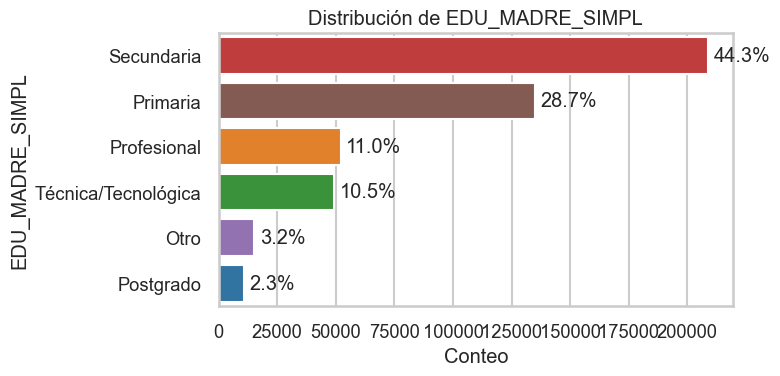

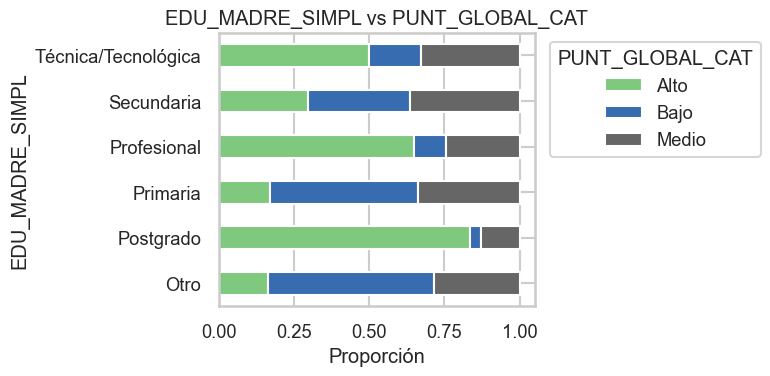

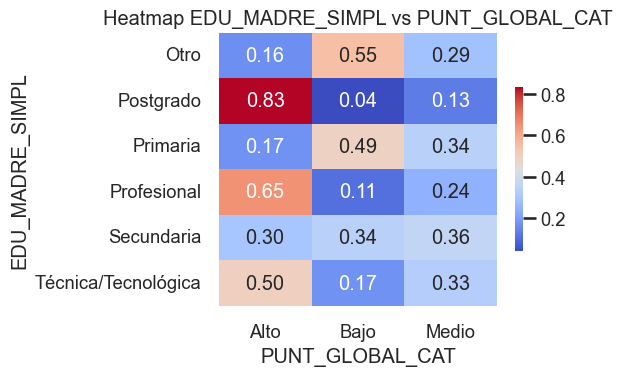

In [ ]:
# --- Ajustes globales de estilo y tamaño de texto ---
sns.set_style('whitegrid')
sns.set_context('talk', font_scale=0.8)

cat_cols = [
    'EDU_MADRE_SIMPL'
]
target = 'PUNT_GLOBAL_CAT'

graficos_categoricos(cat_cols)

In [ ]:
df['EDU_MADRE_FINAL'] = df['EDU_MADRE_SIMPL'].replace({'Otro': 'Primaria'})

new_order = ['Primaria', 'Secundaria', 'Técnica/Tecnológica', 'Profesional', 'Postgrado']
df['EDU_MADRE_FINAL'] = pd.Categorical(
    df['EDU_MADRE_FINAL'],
    categories=new_order,
    ordered=True
)

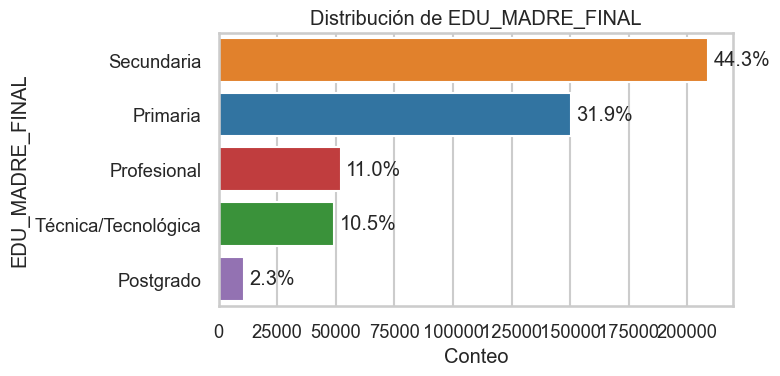

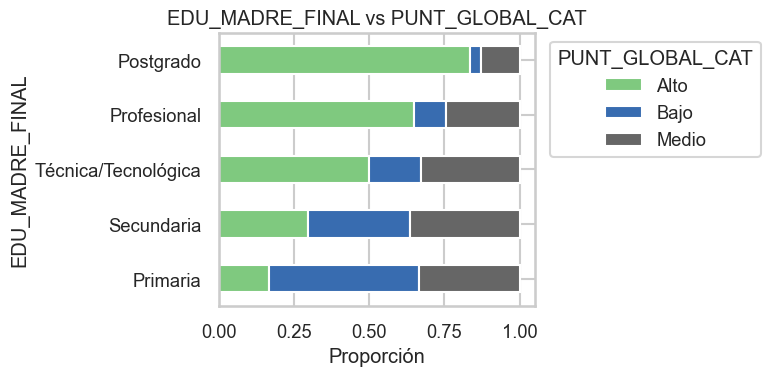

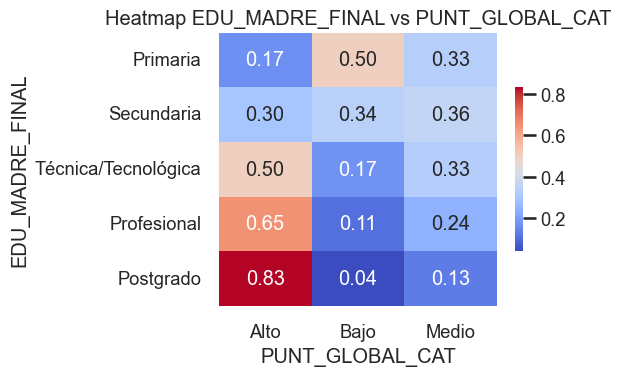

In [ ]:
# --- Ajustes globales de estilo y tamaño de texto ---
sns.set_style('whitegrid')
sns.set_context('talk', font_scale=0.8)

cat_cols = [
    'EDU_MADRE_FINAL'
]
target = 'PUNT_GLOBAL_CAT'

graficos_categoricos(cat_cols)


In [ ]:
df['EDU_MADRE_AGRUP'] = df['FAMI_EDUCACIONMADRE'].replace({
    'No sabe': 'Otro',
    'Ninguno': 'Otro',
    'Educación profesional incompleta': 'Otro'
})

In [ ]:
df = df.drop(columns=['EDU_MADRE_AGRUP', 'EDU_MADRE_SIMPL', 'FAMI_EDUCACIONMADRE'])

In [ ]:
mapping_padre = {
    # Primaria
    'Primaria completa':                    'Primaria',
    'Primaria incompleta':                  'Primaria',
    # Secundaria
    'Secundaria (Bachillerato) completa':   'Secundaria',
    'Secundaria (Bachillerato) incompleta': 'Secundaria',
    # Técnica/Tecnológica
    'Técnica o tecnológica completa':       'Técnica/Tecnológica',
    'Técnica o tecnológica incompleta':     'Técnica/Tecnológica',
    # Profesional
    'Educación profesional completa':       'Profesional',
    'Educación profesional incompleta':     'Profesional',
    # Postgrado
    'Postgrado':                            'Postgrado',
    # Otros (categorías muy pequeñas)
    'Ninguno':                              'Otro',
    'No sabe':                              'Otro'
}

df['EDU_PADRE_SIMPL'] = df['FAMI_EDUCACIONPADRE'].replace(mapping_padre)

# 3) (Opcional) Fusiona “Otro” con “Primaria” → 5 niveles
df['EDU_PADRE_FINAL'] = df['EDU_PADRE_SIMPL'].replace({'Otro': 'Primaria'})

# 4) Define un orden lógico para la categoría final
final_order = ['Primaria','Secundaria','Técnica/Tecnológica','Profesional','Postgrado']
df['EDU_PADRE_FINAL'] = pd.Categorical(
    df['EDU_PADRE_FINAL'],
    categories=final_order,
    ordered=True
)

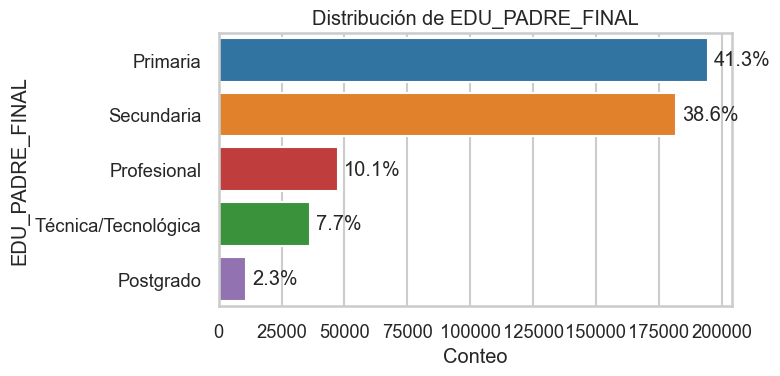

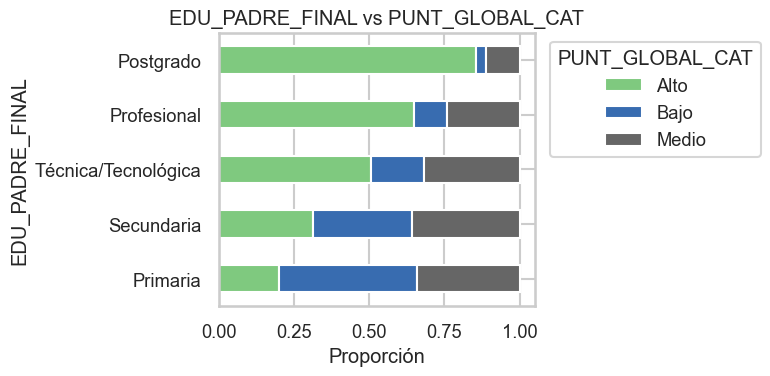

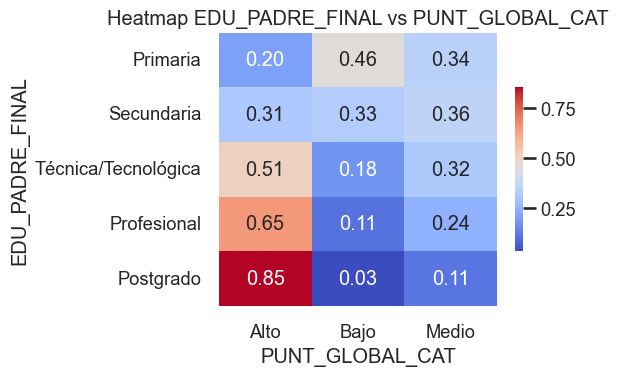

In [ ]:
# --- Ajustes globales de estilo y tamaño de texto ---
sns.set_style('whitegrid')
sns.set_context('talk', font_scale=0.8)

cat_cols = [
    'EDU_PADRE_FINAL'
]
target = 'PUNT_GLOBAL_CAT'

graficos_categoricos(cat_cols)


In [ ]:
df.columns

Index(['COLE_BILINGUE', 'COLE_CALENDARIO', 'COLE_CARACTER', 'COLE_GENERO',
       'ESTU_DEPTO_RESIDE', 'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR',
       'FAMI_TIENEAUTOMOVIL', 'FAMI_TIENECOMPUTADOR', 'FAMI_TIENEINTERNET',
       'FAMI_TIENELAVADORA', 'EDAD', 'PUNT_GLOBAL_CAT', 'COLE_JORNADA_GRUPO',
       'EDU_PADRES_MAX'],
      dtype='object')

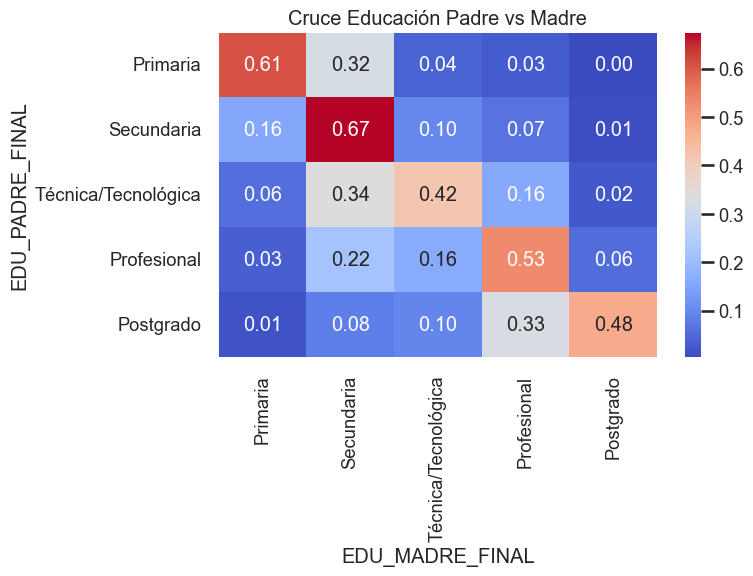

Cramér’s V = 0.446  (p = 0.000)
Mutual Information = 0.277


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.metrics import mutual_info_score

# Asume df ya cargado y con EDU_MADRE_SIMPL y EDU_PADRE_FINAL
# 1) Tabla de contingencia normalizada por fila
ct = pd.crosstab(df['EDU_PADRE_FINAL'], df['EDU_MADRE_FINAL'], normalize='index')

# 2) Heatmap de la cruz
plt.figure(figsize=(8, 6))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Cruce Educación Padre vs Madre')
plt.xlabel('EDU_MADRE_FINAL')
plt.ylabel('EDU_PADRE_FINAL')
plt.tight_layout()
plt.show()

# 3) Cramér’s V
chi2, p, dof, exp = chi2_contingency(pd.crosstab(df['EDU_PADRE_FINAL'], df['EDU_MADRE_FINAL']))
n = df.shape[0]
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape)-1)))
print(f"Cramér’s V = {cramers_v:.3f}  (p = {p:.3f})")

# 4) Información mutua
mi = mutual_info_score(df['EDU_PADRE_FINAL'], df['EDU_MADRE_FINAL'])
print(f"Mutual Information = {mi:.3f}")


In [ ]:
padre = df['EDU_PADRE_FINAL'].cat.codes
madre = df['EDU_MADRE_FINAL'].cat.codes

# calcula el máximo código y vuelve a categoría
max_code = pd.Series(np.maximum(padre, madre), index=df.index)
labels = df['EDU_PADRE_FINAL'].cat.categories  # mismo orden para padre y madre

df['EDU_PADRES_MAX'] = pd.Categorical(
    max_code.map(lambda i: labels[i]),
    categories=labels,
    ordered=True
)


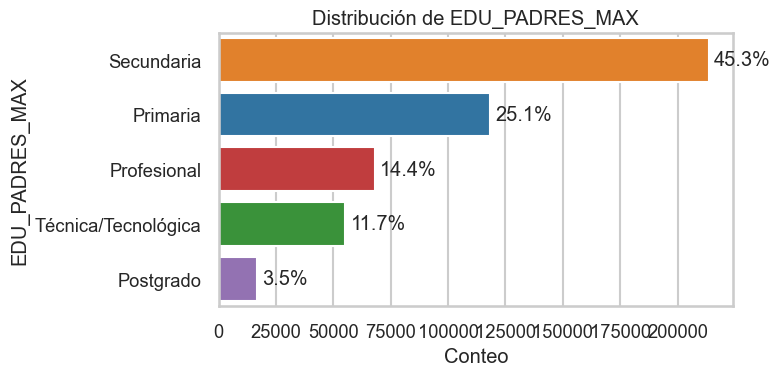

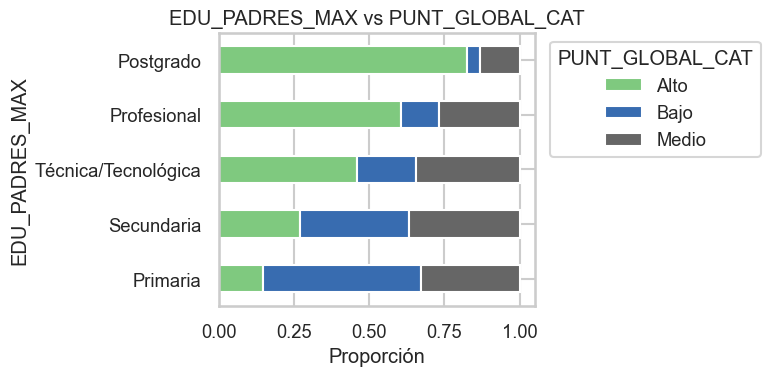

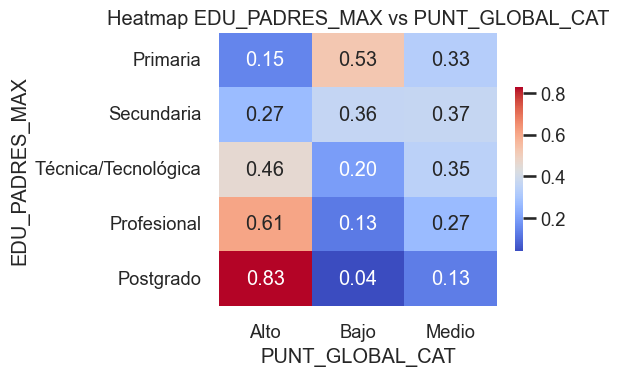

In [ ]:
# --- Ajustes globales de estilo y tamaño de texto ---
sns.set_style('whitegrid')
sns.set_context('talk', font_scale=0.8)

cat_cols = [
    'EDU_PADRES_MAX'
]
target = 'PUNT_GLOBAL_CAT'

graficos_categoricos(cat_cols)


In [ ]:
df.columns

Index(['COLE_BILINGUE', 'COLE_CALENDARIO', 'COLE_CARACTER', 'COLE_GENERO',
       'ESTU_DEPTO_RESIDE', 'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR',
       'FAMI_TIENEAUTOMOVIL', 'FAMI_TIENECOMPUTADOR', 'FAMI_TIENEINTERNET',
       'FAMI_TIENELAVADORA', 'EDAD', 'PUNT_GLOBAL_CAT', 'COLE_JORNADA_GRUPO',
       'EDU_PADRES_MAX'],
      dtype='object')

In [ ]:
df = df.drop(columns=['EDU_PADRE_SIMPL', 'FAMI_EDUCACIONPADRE', 'EDU_PADRE_FINAL', 'EDU_MADRE_FINAL', 'COLE_JORNADA'])

In [ ]:
df.columns

Index(['COLE_BILINGUE', 'COLE_CALENDARIO', 'COLE_CARACTER', 'COLE_GENERO',
       'ESTU_DEPTO_RESIDE', 'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR',
       'FAMI_TIENEAUTOMOVIL', 'FAMI_TIENECOMPUTADOR', 'FAMI_TIENEINTERNET',
       'FAMI_TIENELAVADORA', 'EDAD', 'PUNT_GLOBAL_CAT', 'COLE_JORNADA_GRUPO',
       'EDU_PADRES_MAX'],
      dtype='object')

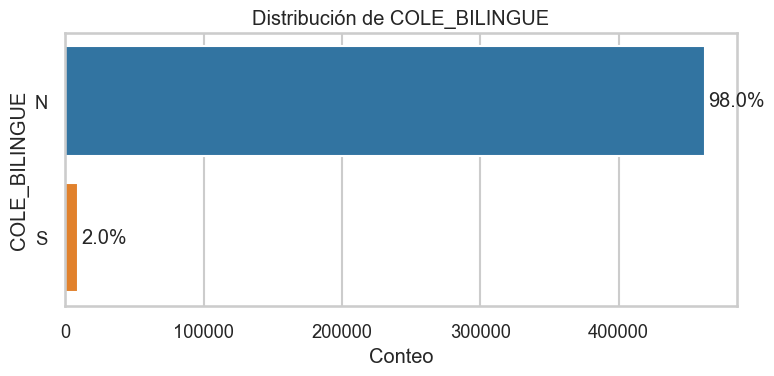

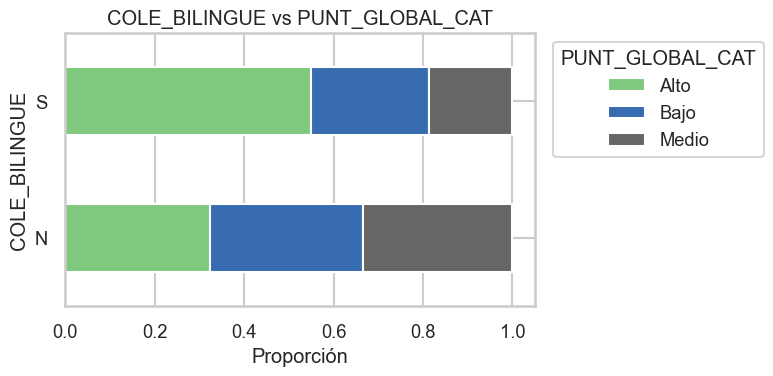

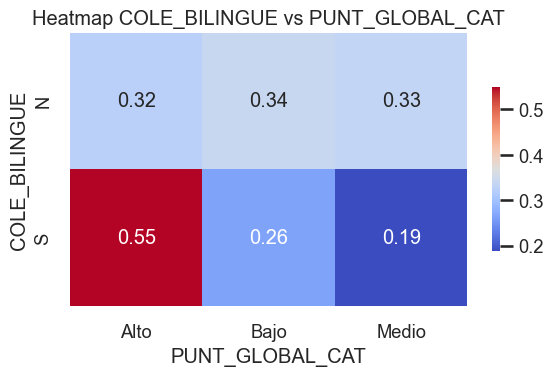

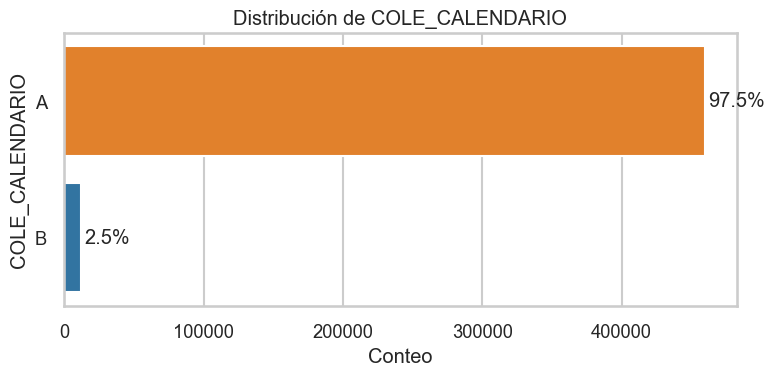

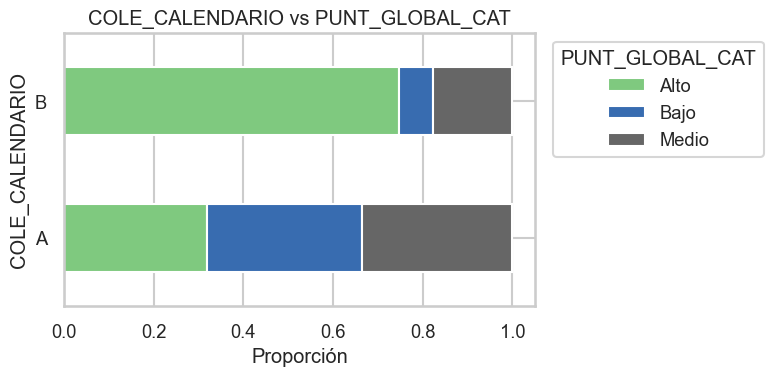

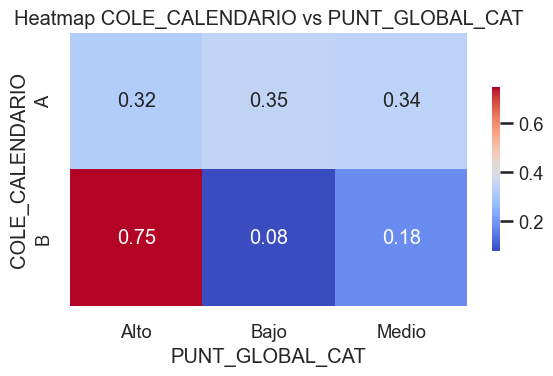

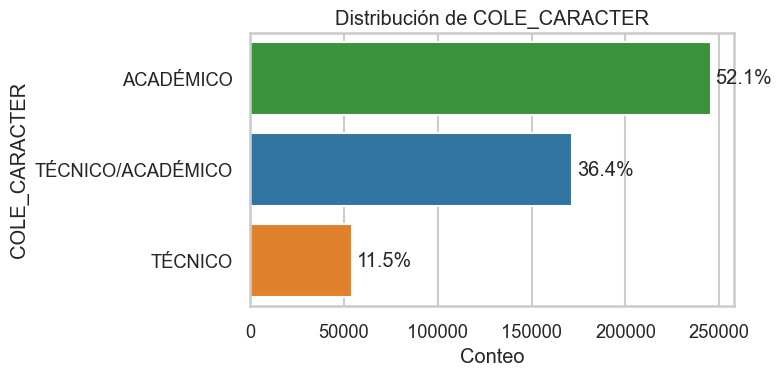

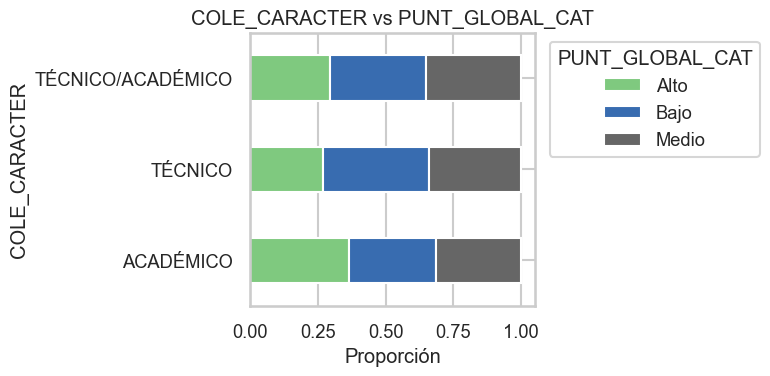

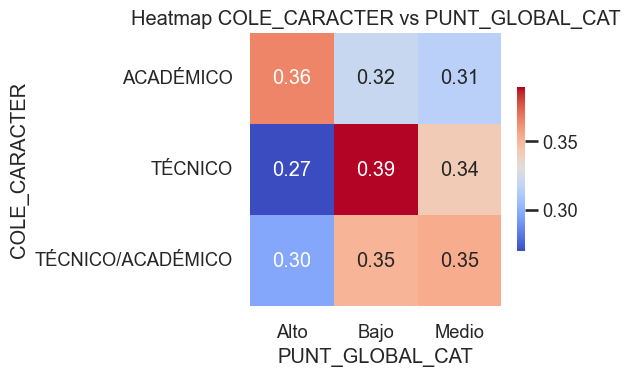

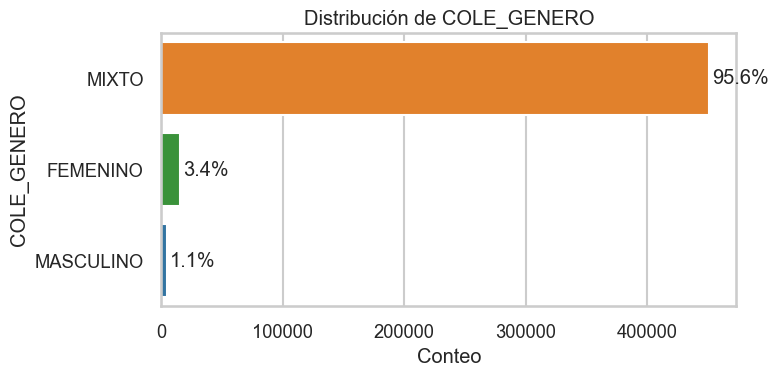

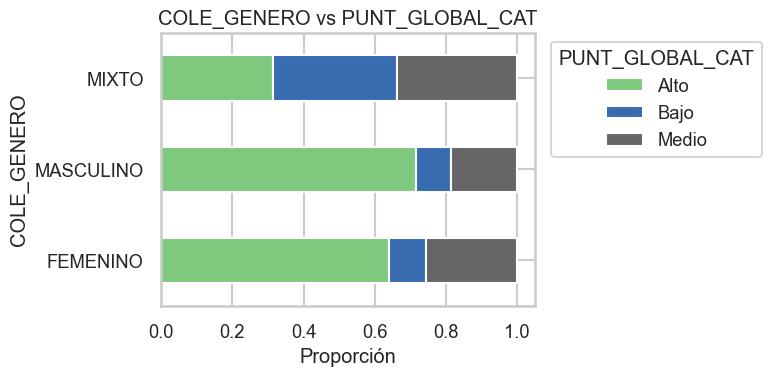

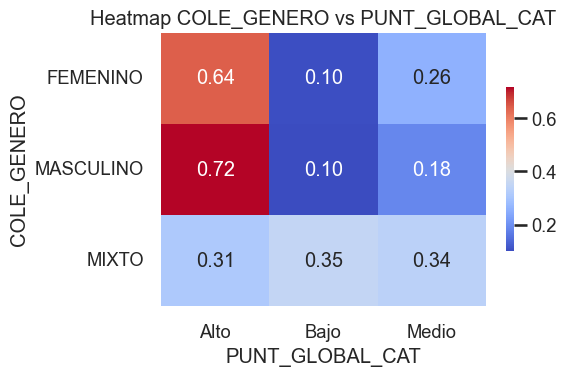

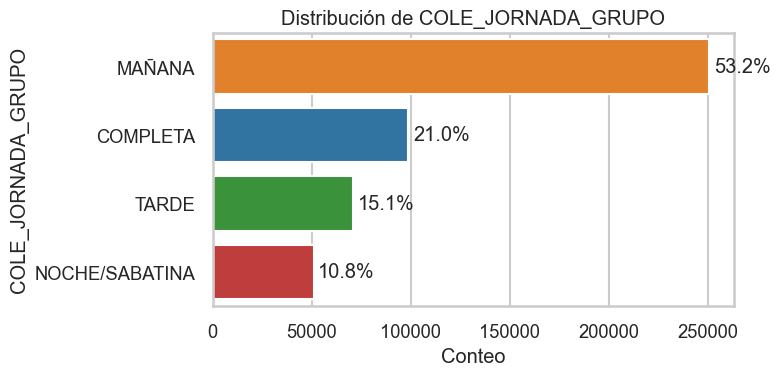

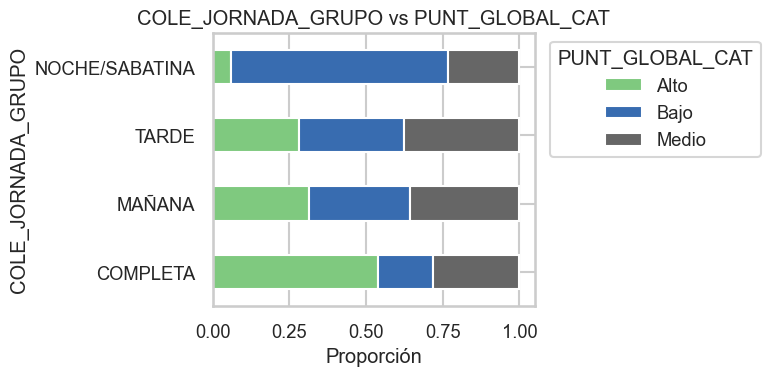

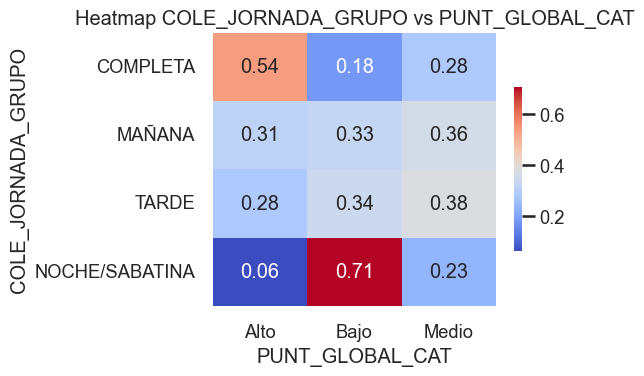

C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\3057528669.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=45, ha='right')


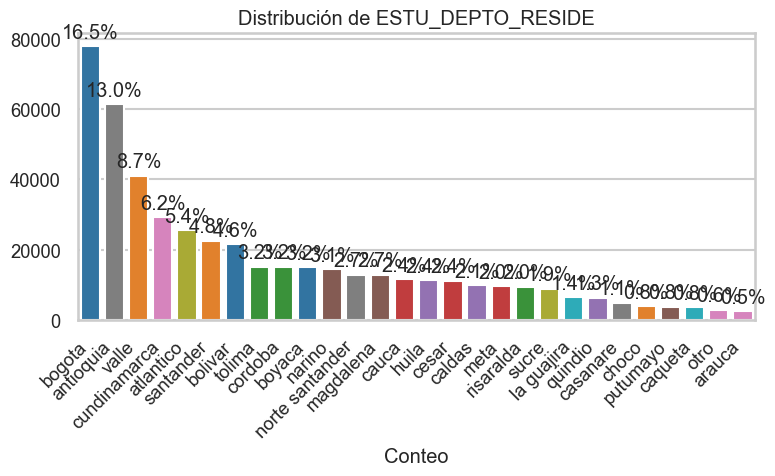

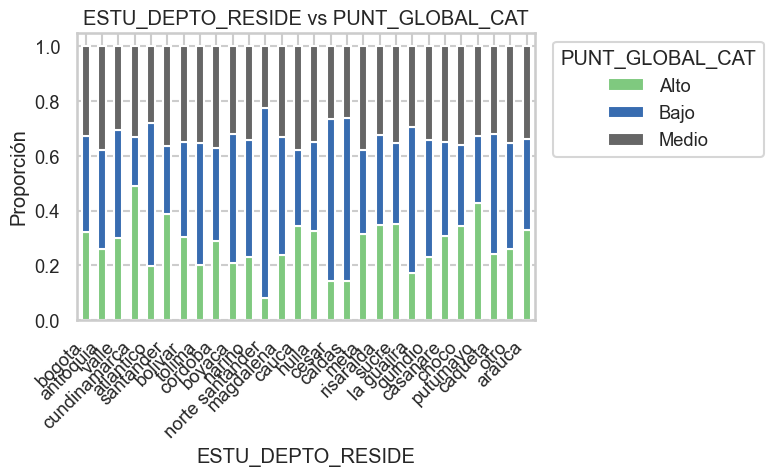

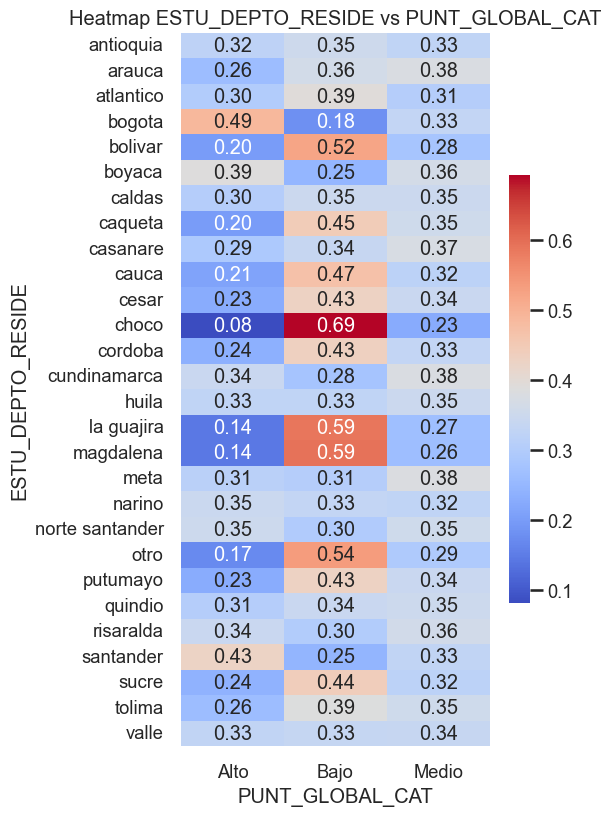

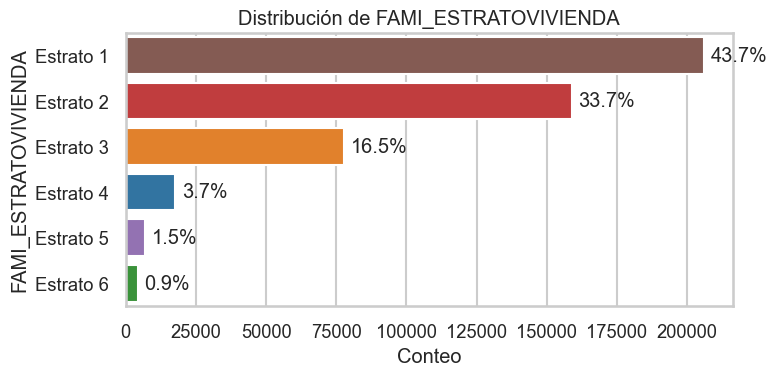

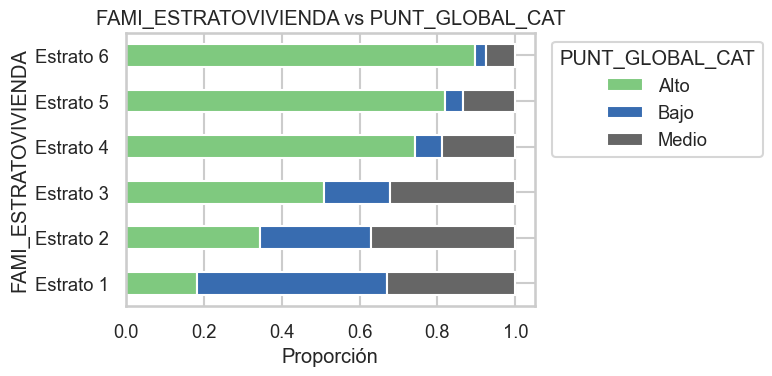

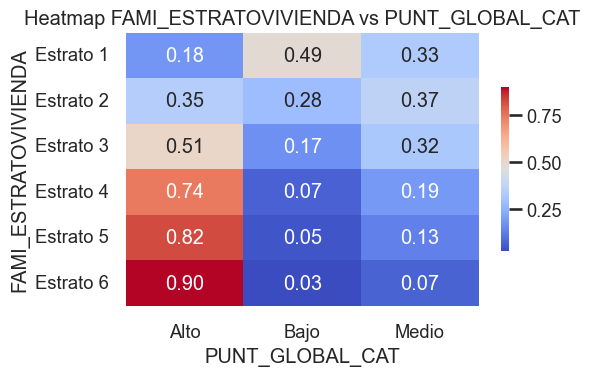

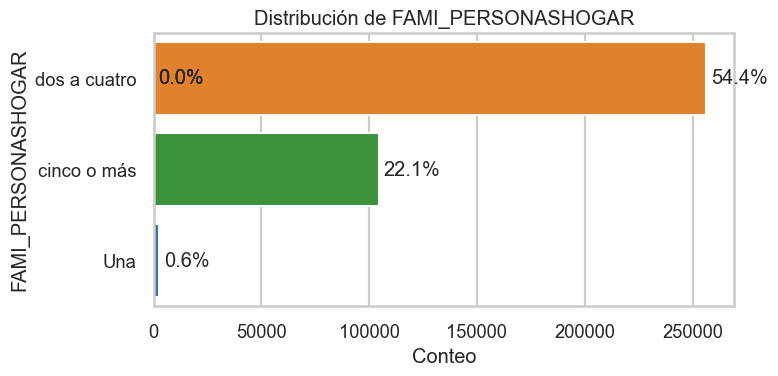

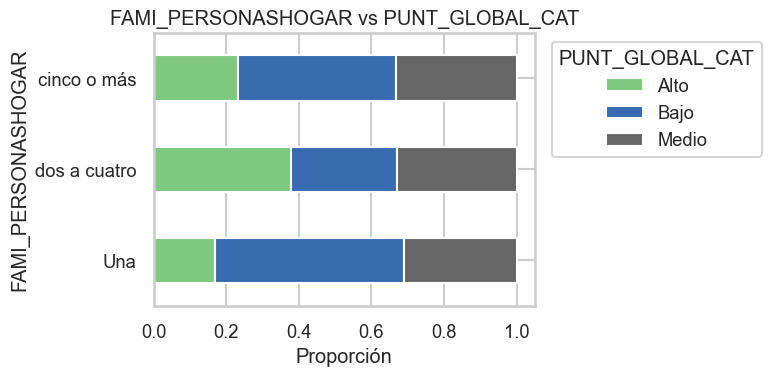

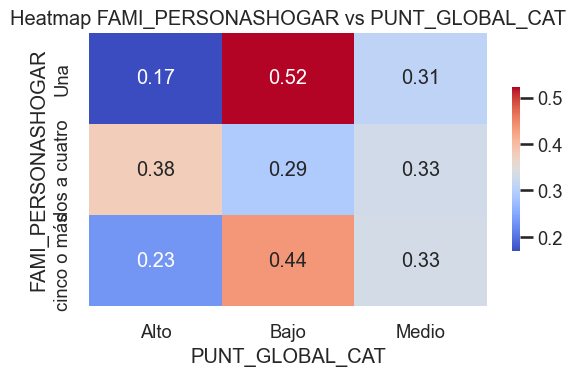

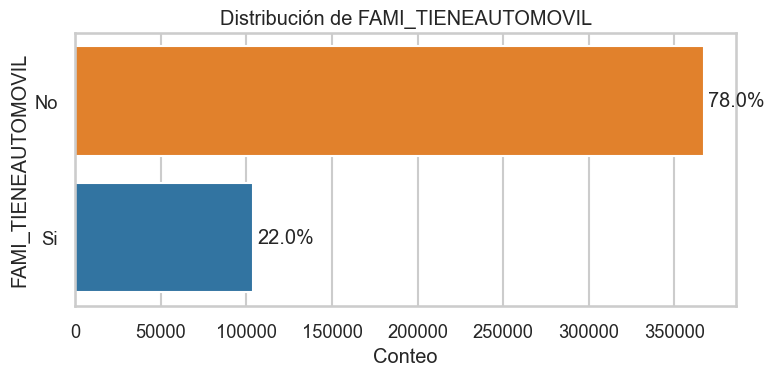

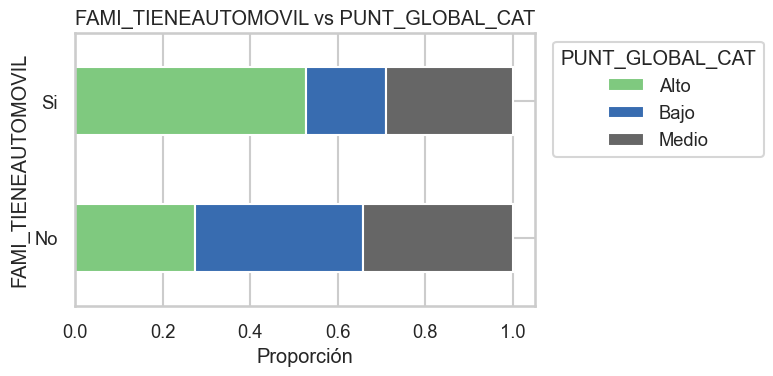

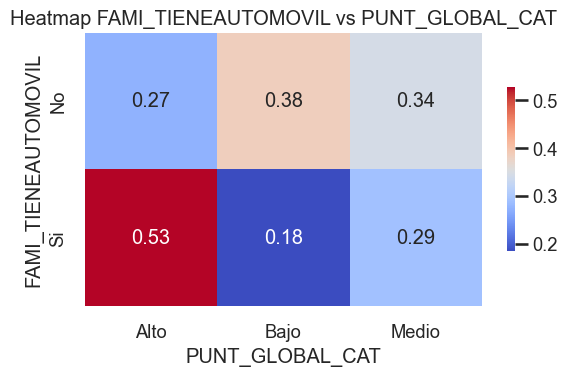

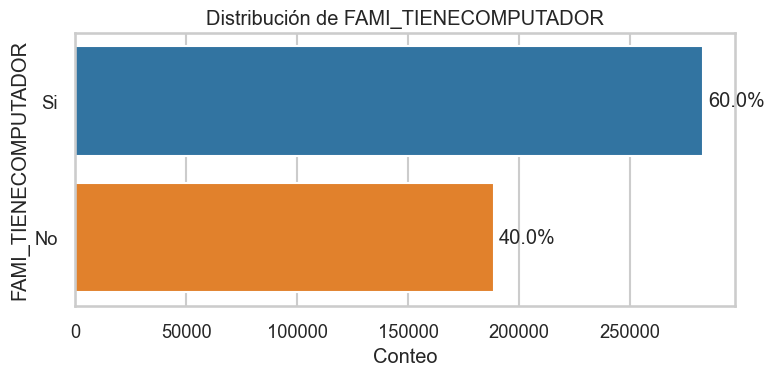

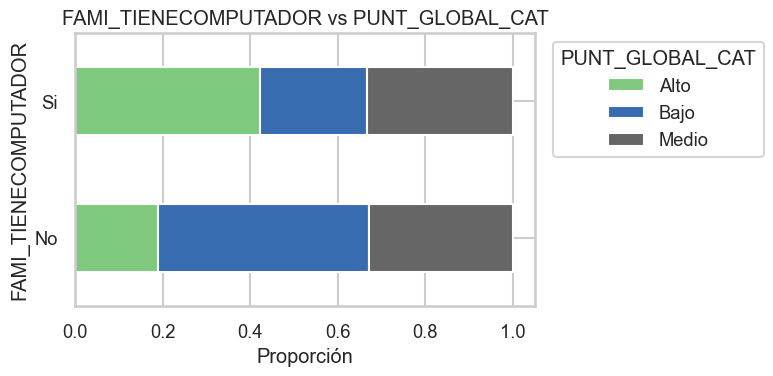

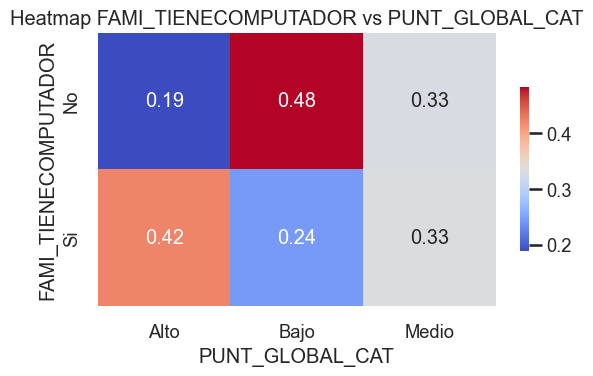

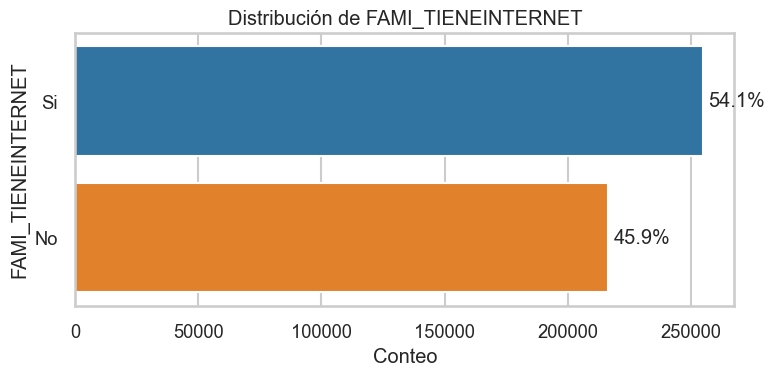

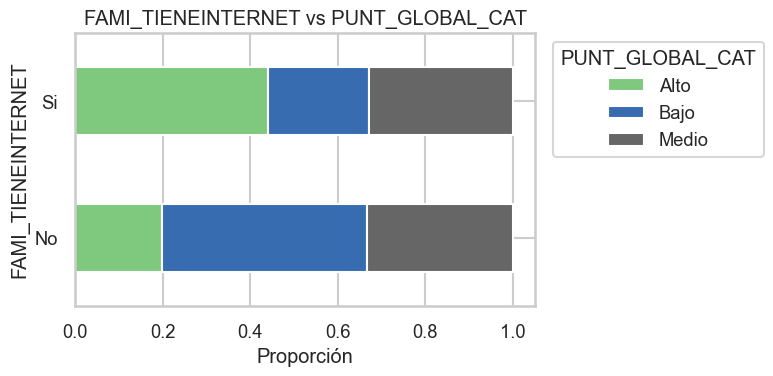

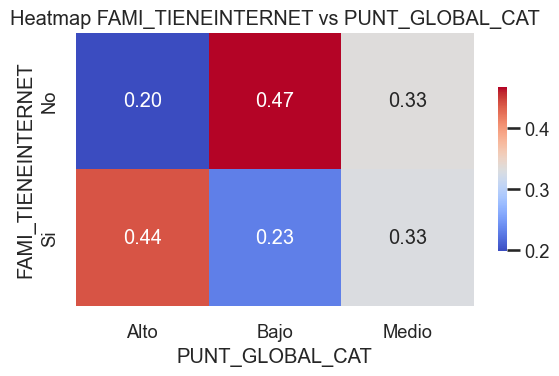

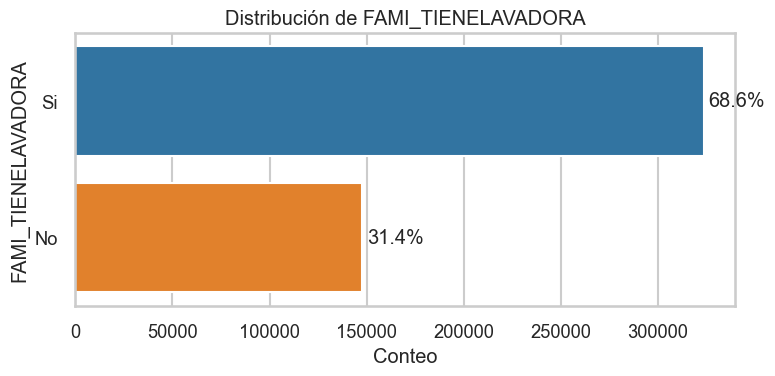

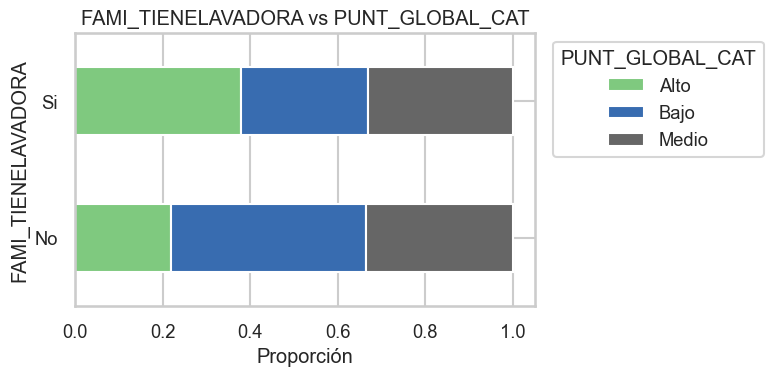

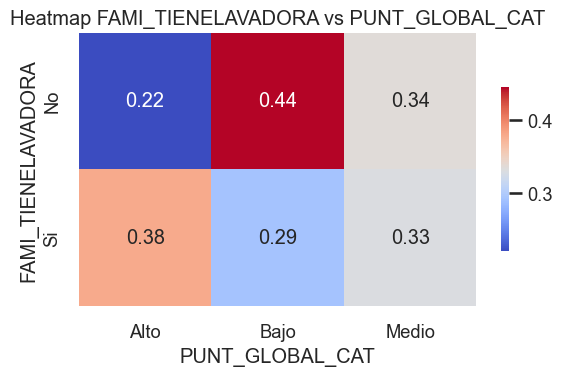

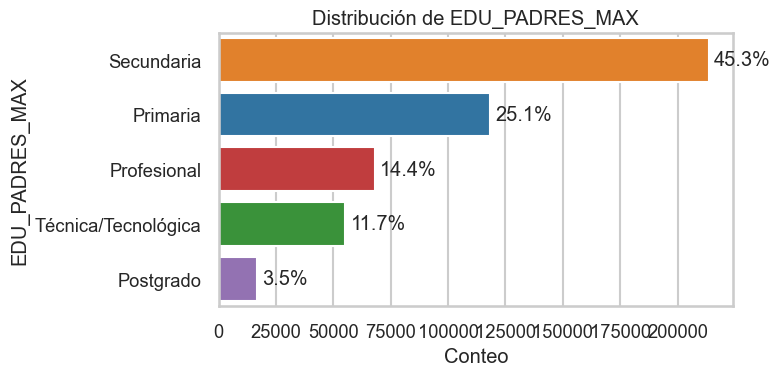

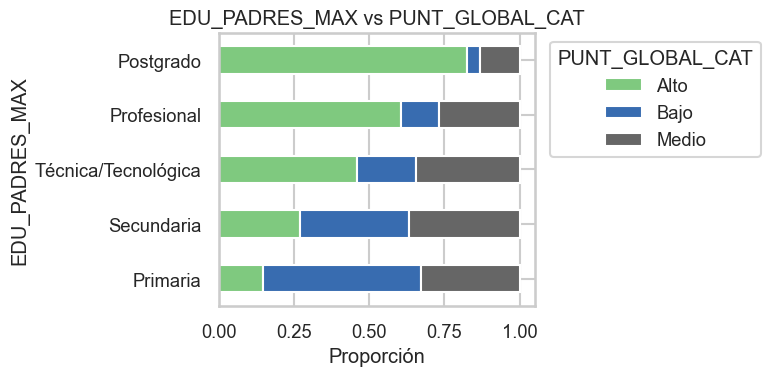

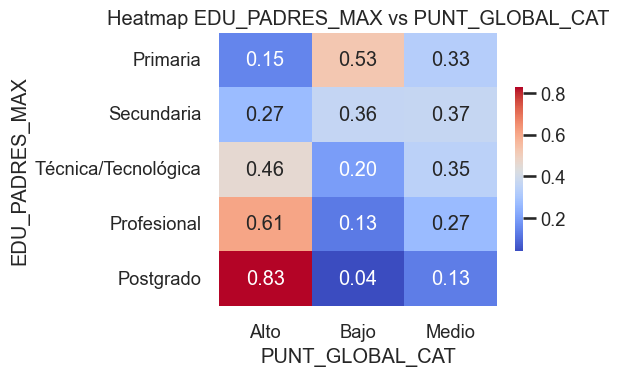

In [ ]:
# --- Ajustes globales de estilo y tamaño de texto ---
sns.set_style('whitegrid')
sns.set_context('talk', font_scale=0.8)

cat_cols = ['COLE_BILINGUE', 'COLE_CALENDARIO', 'COLE_CARACTER', 'COLE_GENERO',
       'COLE_JORNADA_GRUPO', 'ESTU_DEPTO_RESIDE', 'FAMI_ESTRATOVIVIENDA',
       'FAMI_PERSONASHOGAR', 'FAMI_TIENEAUTOMOVIL', 'FAMI_TIENECOMPUTADOR',
       'FAMI_TIENEINTERNET', 'FAMI_TIENELAVADORA',
       'EDU_PADRES_MAX']
target = 'PUNT_GLOBAL_CAT'

graficos_categoricos(cat_cols)

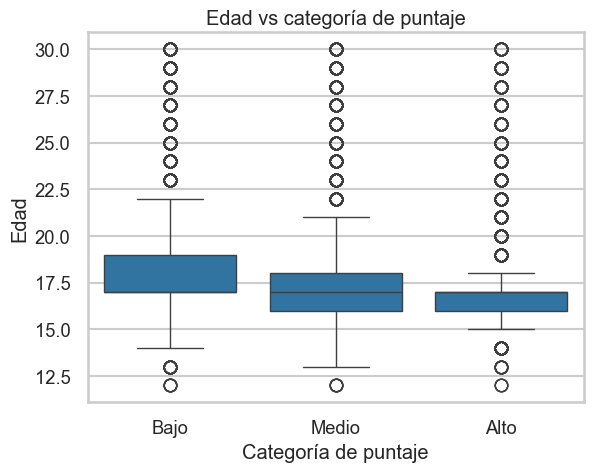

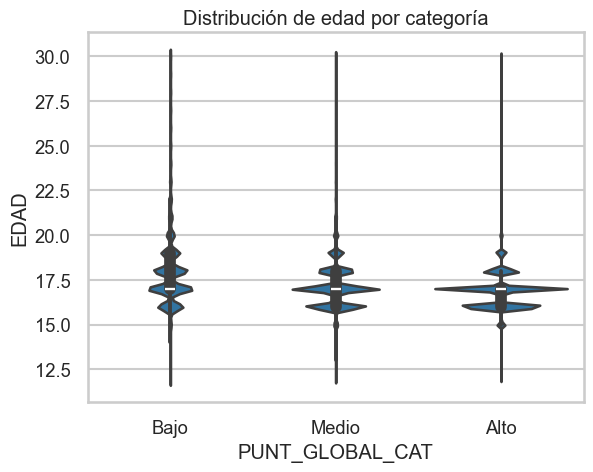

In [ ]:
# a) Boxplot de edad por categoría de puntaje
sns.boxplot(
    x='PUNT_GLOBAL_CAT',
    y='EDAD',
    data=df,
    order=['Bajo','Medio','Alto']
)
plt.title("Edad vs categoría de puntaje")
plt.xlabel("Categoría de puntaje")
plt.ylabel("Edad")
plt.show()

# b) Violín para densidad
sns.violinplot(
    x='PUNT_GLOBAL_CAT',
    y='EDAD',
    data=df,
    order=['Bajo','Medio','Alto']
)
plt.title("Distribución de edad por categoría")
plt.show()


In [ ]:
from scipy.stats import f_oneway, kruskal

grupos = [ df.loc[df['PUNT_GLOBAL_CAT']==c, 'EDAD'] for c in ['Bajo','Medio','Alto'] ]

# ANOVA
f, p_anova = f_oneway(*grupos)
print(f"ANOVA: F={f:.2f}, p={p_anova:.3f}")

# Kruskal (no paramétrico)
h, p_kruskal = kruskal(*grupos)
print(f"Kruskal-Wallis: H={h:.2f}, p={p_kruskal:.3f}")


ANOVA: F=20478.43, p=0.000
Kruskal-Wallis: H=39356.85, p=0.000


In [ ]:
stats = df.groupby('PUNT_GLOBAL_CAT')['EDAD'].agg(
    count='count',
    mean='mean',
    std='std',
    median='median'
)
print(stats)

grand_mean = df['EDAD'].mean()
# Suma de cuadrados entre grupos
ss_between = sum(
    stats['count'] * (stats['mean'] - grand_mean)**2
)
# Suma de cuadrados total
ss_total = ((df['EDAD'] - grand_mean)**2).sum()
eta2 = ss_between / ss_total
print(f"Eta² = {eta2:.3f}")


                  count       mean       std  median
PUNT_GLOBAL_CAT                                     
Alto             155084  16.851648  1.027061    17.0
Bajo             159976  18.003038  2.192673    17.0
Medio            156497  17.212828  1.450625    17.0
Eta² = 0.080


C:\Users\Rodhy\AppData\Local\Temp\ipykernel_36448\2744667425.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = df.groupby('PUNT_GLOBAL_CAT')['EDAD'].agg(


In [ ]:
df.columns

Index(['COLE_BILINGUE', 'COLE_CALENDARIO', 'COLE_CARACTER', 'COLE_GENERO',
       'ESTU_DEPTO_RESIDE', 'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR',
       'FAMI_TIENEAUTOMOVIL', 'FAMI_TIENECOMPUTADOR', 'FAMI_TIENEINTERNET',
       'FAMI_TIENELAVADORA', 'EDAD', 'PUNT_GLOBAL_CAT', 'COLE_JORNADA_GRUPO',
       'EDU_PADRES_MAX'],
      dtype='object')

In [ ]:
for col in df.columns:
    print(f"Columna: {col}")
    print(df[col].unique())
    print('-' * 40)

In [ ]:
df.to_csv('datos_limpios_3.csv', index=False, encoding='utf-8')